In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sksurv.util import Surv
from sksurv.linear_model import CoxPHSurvivalAnalysis, CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

In [2]:
project_dir = Path(r"C:\Multimodal_KIRC_Project")
processed_dir = project_dir / "03_processed_data"

print(project_dir)

C:\Multimodal_KIRC_Project


In [3]:
counts = pd.read_csv(
    processed_dir / "TCGA_KIRC_raw_gene_count_matrix.csv",
    index_col="Case ID"
)

gene_annotation = pd.read_csv(
    processed_dir / "TCGA_KIRC_gene_annotation.csv"
)

clinical_survival = pd.read_csv(
    processed_dir / "TCGA_KIRC_clinical_survival_harmonized.csv"
)

pfi_eligible = pd.read_csv(
    processed_dir / "TCGA_KIRC_final_PFI_cohort.csv"
)

print("Raw counts:", counts.shape)
print("Clinical-survival:", clinical_survival.shape)
print("PFI eligible:", pfi_eligible.shape)

Raw counts: (533, 60660)
Clinical-survival: (533, 23)
PFI eligible: (529, 34)


In [4]:
pfi_outcome = (
    pfi_eligible[
        ["Case ID", "PFI", "PFI.time"]
    ]
    .set_index("Case ID")
    .rename(
        columns={
            "PFI": "event",
            "PFI.time": "time"
        }
    )
)

pfi_outcome["event"] = (
    pfi_outcome["event"]
    .astype(int)
)

pfi_outcome["time"] = (
    pfi_outcome["time"]
    .astype(float)
)

print("PFI patients:", len(pfi_outcome))
print("PFI events:", pfi_outcome["event"].sum())
print("Censored:", (pfi_outcome["event"] == 0).sum())

assert len(pfi_outcome) == 529
assert pfi_outcome["event"].sum() == 159
assert (pfi_outcome["time"] > 0).all()

PFI patients: 529
PFI events: 159
Censored: 370


In [5]:
pfi_ids = pfi_outcome.index.tolist()

clinical_pfi = (
    clinical_survival
    .set_index("Case ID")
    .loc[pfi_ids]
    .copy()
)

clinical_features = clinical_pfi[
    [
        "Age at Index",
        "Tumor Grade",
        "AJCC Stage"
    ]
].copy()

clinical_features.columns = [
    "age",
    "grade",
    "stage"
]

assert clinical_features.index.equals(
    pfi_outcome.index
)

display(clinical_features.head())

print("\nMissing:")
print(clinical_features.isna().sum())

,age,grade,stage
Case ID,,,
TCGA-3Z-A93Z,69,G2,Stage I
TCGA-6D-AA2E,68,G2,Stage I
TCGA-A3-3306,67,G3,Stage I
TCGA-A3-3307,66,G3,Stage III
TCGA-A3-3308,77,G2,Stage III



Missing:
age       0
grade    10
stage     3
dtype: int64


In [6]:
protein_coding_ids = set(
    gene_annotation.loc[
        gene_annotation["gene_type"] == "protein_coding",
        "gene_id"
    ]
)

protein_columns = [
    gene
    for gene in counts.columns
    if gene in protein_coding_ids
]

counts_protein = (
    counts
    .loc[pfi_ids, protein_columns]
    .copy()
)

print(
    "Protein-coding RNA matrix:",
    counts_protein.shape
)

assert counts_protein.shape[0] == 529

Protein-coding RNA matrix: (529, 19962)


In [7]:
N_REPEATS = 10
N_OUTER_FOLDS = 5
BASE_SEED = 2026

repeated_fold_rows = []

for repeat in range(1, N_REPEATS + 1):

    outer_cv = StratifiedKFold(
        n_splits=N_OUTER_FOLDS,
        shuffle=True,
        random_state=BASE_SEED + repeat
    )

    for fold, (_, test_idx) in enumerate(
        outer_cv.split(
            np.zeros(len(pfi_outcome)),
            pfi_outcome["event"].values
        ),
        start=1
    ):

        test_cases = (
            pfi_outcome
            .iloc[test_idx]
            .index
        )

        for case_id in test_cases:

            repeated_fold_rows.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,
                "PFI_event":
                    int(
                        pfi_outcome.loc[
                            case_id,
                            "event"
                        ]
                    ),
                "PFI_time":
                    float(
                        pfi_outcome.loc[
                            case_id,
                            "time"
                        ]
                    )
            })

repeated_folds = pd.DataFrame(
    repeated_fold_rows
)

print(
    "Total fold-assignment rows:",
    len(repeated_folds)
)

Total fold-assignment rows: 5290


In [8]:
repeat_fold_audit = (
    repeated_folds
    .groupby(
        ["Repeat", "Fold"]
    )
    .agg(
        Patients=("Case ID", "count"),
        Events=("PFI_event", "sum")
    )
    .reset_index()
)

display(
    repeat_fold_audit.head(15)
)

print(
    "Number of outer evaluations:",
    len(repeat_fold_audit)
)

print(
    "\nPatient-count distribution:"
)

display(
    repeat_fold_audit[
        "Patients"
    ].value_counts()
)

print(
    "\nEvent-count distribution:"
)

display(
    repeat_fold_audit[
        "Events"
    ].value_counts()
)

,Repeat,Fold,Patients,Events
0,1,1,106,32
1,1,2,106,32
2,1,3,106,32
3,1,4,106,32
4,1,5,105,31
5,2,1,106,32
6,2,2,106,32
7,2,3,106,32
8,2,4,106,32
9,2,5,105,31


Number of outer evaluations: 50

Patient-count distribution:


Patients
106    40
105    10
Name: count, dtype: int64


Event-count distribution:


Events
32    40
31    10
Name: count, dtype: int64

In [9]:
patient_repeat_counts = (
    repeated_folds
    .groupby(
        ["Repeat", "Case ID"]
    )
    .size()
)

print(
    "Minimum assignments per patient per repeat:",
    patient_repeat_counts.min()
)

print(
    "Maximum assignments per patient per repeat:",
    patient_repeat_counts.max()
)

assert patient_repeat_counts.min() == 1
assert patient_repeat_counts.max() == 1

print(
    "\nRepeated outer-fold structure passed all checks."
)

Minimum assignments per patient per repeat: 1
Maximum assignments per patient per repeat: 1

Repeated outer-fold structure passed all checks.


In [10]:
repeated_folds.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_outer_fold_assignments.csv",
    index=False
)

repeat_fold_audit.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_outer_fold_audit.csv",
    index=False
)

print("Repeated CV partition plan saved.")

Repeated CV partition plan saved.


In [11]:
# ============================================================
# REPEATED 10 x 5 CLINICAL-ONLY OUTER CV
# ============================================================

repeated_clinical_results = []
repeated_clinical_predictions = []

numeric_features = ["age"]
categorical_features = ["grade", "stage"]

for repeat in range(1, N_REPEATS + 1):

    print(f"\n{'='*60}")
    print(f"REPEAT {repeat} OF {N_REPEATS}")
    print(f"{'='*60}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ].copy()

    for fold in range(1, N_OUTER_FOLDS + 1):

        print(
            f"Clinical model: "
            f"repeat {repeat}, fold {fold}"
        )

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        X_train = clinical_features.loc[
            train_ids
        ].copy()

        X_test = clinical_features.loc[
            test_ids
        ].copy()

        y_train_df = pfi_outcome.loc[
            train_ids
        ]

        y_test_df = pfi_outcome.loc[
            test_ids
        ]

        # ------------------------------------------------
        # Build a FRESH preprocessing object for this fold
        # ------------------------------------------------
        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ])

        preprocessor = ColumnTransformer([
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ])

        clinical_pipeline = Pipeline([
            (
                "preprocessor",
                preprocessor
            ),
            (
                "cox",
                CoxPHSurvivalAnalysis(
                    alpha=0.01
                )
            )
        ])

        y_train = Surv.from_arrays(
            event=y_train_df[
                "event"
            ].astype(bool).to_numpy(),

            time=y_train_df[
                "time"
            ].astype(float).to_numpy()
        )

        y_test = Surv.from_arrays(
            event=y_test_df[
                "event"
            ].astype(bool).to_numpy(),

            time=y_test_df[
                "time"
            ].astype(float).to_numpy()
        )

        # ------------------------------------------------
        # Fit only on outer-training patients
        # ------------------------------------------------
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            clinical_pipeline.fit(
                X_train,
                y_train
            )

        risk_test = clinical_pipeline.predict(
            X_test
        )

        cindex = concordance_index_censored(
            y_test["event"],
            y_test["time"],
            risk_test
        )[0]

        repeated_clinical_results.append({
            "Repeat": repeat,
            "Fold": fold,
            "Train N": len(train_ids),
            "Test N": len(test_ids),
            "Test Events": int(
                y_test_df["event"].sum()
            ),
            "C-index": float(cindex)
        })

        for case_id, score in zip(
            test_ids,
            risk_test
        ):

            repeated_clinical_predictions.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,
                "PFI_event": int(
                    y_test_df.loc[
                        case_id,
                        "event"
                    ]
                ),
                "PFI_time": float(
                    y_test_df.loc[
                        case_id,
                        "time"
                    ]
                ),
                "Clinical_Risk": float(score)
            })


# ============================================================
# CONVERT RESULTS
# ============================================================

repeated_clinical_results = pd.DataFrame(
    repeated_clinical_results
)

repeated_clinical_predictions = pd.DataFrame(
    repeated_clinical_predictions
)

display(
    repeated_clinical_results.head(15)
)

print(
    "\nNumber of outer evaluations:",
    len(repeated_clinical_results)
)

print(
    "Mean repeated clinical C-index:",
    repeated_clinical_results[
        "C-index"
    ].mean()
)

print(
    "SD repeated clinical C-index:",
    repeated_clinical_results[
        "C-index"
    ].std(ddof=1)
)

print(
    "Median repeated clinical C-index:",
    repeated_clinical_results[
        "C-index"
    ].median()
)

print(
    "Minimum C-index:",
    repeated_clinical_results[
        "C-index"
    ].min()
)

print(
    "Maximum C-index:",
    repeated_clinical_results[
        "C-index"
    ].max()
)


REPEAT 1 OF 10
Clinical model: repeat 1, fold 1
Clinical model: repeat 1, fold 2
Clinical model: repeat 1, fold 3


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Clinical model: repeat 1, fold 4
Clinical model: repeat 1, fold 5

REPEAT 2 OF 10
Clinical model: repeat 2, fold 1
Clinical model: repeat 2, fold 2
Clinical model: repeat 2, fold 3
Clinical model: repeat 2, fold 4


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Clinical model: repeat 2, fold 5

REPEAT 3 OF 10
Clinical model: repeat 3, fold 1
Clinical model: repeat 3, fold 2
Clinical model: repeat 3, fold 3


...

Clinical model: repeat 9, fold 4
Clinical model: repeat 9, fold 5

REPEAT 10 OF 10
Clinical model: repeat 10, fold 1
Clinical model: repeat 10, fold 2
Clinical model: repeat 10, fold 3
Clinical model: repeat 10, fold 4


C:\Users\kumia\miniforge3\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Clinical model: repeat 10, fold 5


,Repeat,Fold,Train N,Test N,Test Events,C-index
0,1,1,423,106,32,0.816327
1,1,2,423,106,32,0.748747
2,1,3,423,106,32,0.853142
3,1,4,423,106,32,0.836154
4,1,5,424,105,31,0.820575
5,2,1,423,106,32,0.843321
6,2,2,423,106,32,0.794201
7,2,3,423,106,32,0.817791
8,2,4,423,106,32,0.748568
9,2,5,424,105,31,0.814727



Number of outer evaluations: 50
Mean repeated clinical C-index: 0.8120059057614811
SD repeated clinical C-index: 0.03735985336920903
Median repeated clinical C-index: 0.8178922569504576
Minimum C-index: 0.7178719484108705
Maximum C-index: 0.8677390527256479


In [12]:
assert len(repeated_clinical_results) == 50

assert len(
    repeated_clinical_predictions
) == 5290

assert (
    repeated_clinical_predictions
    .groupby(["Repeat", "Case ID"])
    .size()
    .eq(1)
    .all()
)

print(
    "All repeated clinical-CV integrity checks passed."
)

All repeated clinical-CV integrity checks passed.


In [13]:
repeated_clinical_results.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_clinical_outer_results.csv",
    index=False
)

repeated_clinical_predictions.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_clinical_predictions.csv",
    index=False
)

print("Repeated clinical results saved.")

Repeated clinical results saved.


In [14]:
def preprocess_rna_train_test(
    X_train_counts,
    X_test_counts,
    min_count=10,
    min_fraction=0.20,
    top_k=250
):
    min_patients = int(
        np.ceil(
            min_fraction *
            X_train_counts.shape[0]
        )
    )

    keep_genes = (
        (X_train_counts >= min_count)
        .sum(axis=0)
        >= min_patients
    )

    selected_genes = X_train_counts.columns[
        keep_genes
    ]

    X_train = X_train_counts[
        selected_genes
    ].copy()

    X_test = X_test_counts[
        selected_genes
    ].copy()

    # CPM
    train_library = X_train.sum(axis=1)
    test_library = X_test.sum(axis=1)

    X_train_cpm = (
        X_train.div(
            train_library,
            axis=0
        ) * 1_000_000
    )

    X_test_cpm = (
        X_test.div(
            test_library,
            axis=0
        ) * 1_000_000
    )

    # log2(CPM + 1)
    X_train_log = np.log2(
        X_train_cpm + 1
    )

    X_test_log = np.log2(
        X_test_cpm + 1
    )

    # Training-only variance ranking
    train_variances = (
        X_train_log.var(axis=0)
    )

    top_genes = (
        train_variances
        .sort_values(
            ascending=False
        )
        .head(
            min(
                top_k,
                len(train_variances)
            )
        )
        .index
    )

    X_train_log = X_train_log[
        top_genes
    ]

    X_test_log = X_test_log[
        top_genes
    ]

    # Training-only standardization
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(
        X_train_log
    )

    X_test_scaled = scaler.transform(
        X_test_log
    )

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "genes": list(top_genes),
        "n_prevalence_genes":
            len(selected_genes)
    }


print("RNA preprocessing function loaded.")

RNA preprocessing function loaded.


In [15]:
print(tune_coxnet_inner_cv)

NameError: name 'tune_coxnet_inner_cv' is not defined

In [16]:
from sklearn.model_selection import StratifiedKFold
from sksurv.util import Surv
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

import warnings
import numpy as np
import pandas as pd


def tune_coxnet_inner_cv(
    X,
    y_event,
    y_time,
    l1_ratios=(0.5, 0.9, 1.0),
    n_splits=3,
    random_state=2026,
    n_alphas=12
):

    inner_cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    tuning_rows = []

    for l1_ratio in l1_ratios:

        y_outer_train = Surv.from_arrays(
            event=y_event.astype(bool),
            time=y_time.astype(float)
        )

        path_model = CoxnetSurvivalAnalysis(
            l1_ratio=l1_ratio,
            n_alphas=n_alphas,
            alpha_min_ratio=0.01,
            max_iter=150000,
            tol=1e-6
        )

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                path_model.fit(
                    X,
                    y_outer_train
                )

        except Exception:
            continue

        candidate_alphas = path_model.alphas_

        for alpha in candidate_alphas:

            fold_scores = []

            for train_idx, val_idx in inner_cv.split(
                X,
                y_event
            ):

                y_train = Surv.from_arrays(
                    event=y_event[
                        train_idx
                    ].astype(bool),

                    time=y_time[
                        train_idx
                    ].astype(float)
                )

                y_val = Surv.from_arrays(
                    event=y_event[
                        val_idx
                    ].astype(bool),

                    time=y_time[
                        val_idx
                    ].astype(float)
                )

                model = CoxnetSurvivalAnalysis(
                    l1_ratio=l1_ratio,
                    alphas=[alpha],
                    max_iter=150000,
                    tol=1e-6
                )

                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")

                        model.fit(
                            X[train_idx],
                            y_train
                        )

                    coef = np.asarray(
                        model.coef_
                    ).ravel()

                    if np.all(
                        np.abs(coef) < 1e-12
                    ):
                        continue

                    risk = model.predict(
                        X[val_idx]
                    )

                    if not np.isfinite(
                        risk
                    ).all():
                        continue

                    cindex = concordance_index_censored(
                        y_val["event"],
                        y_val["time"],
                        risk
                    )[0]

                    if np.isfinite(cindex):
                        fold_scores.append(
                            float(cindex)
                        )

                except Exception:
                    continue

            if len(fold_scores) >= 3:

                tuning_rows.append({
                    "l1_ratio":
                        float(l1_ratio),

                    "alpha":
                        float(alpha),

                    "valid_inner_folds":
                        len(fold_scores),

                    "mean_inner_cindex":
                        float(
                            np.mean(
                                fold_scores
                            )
                        ),

                    "sd_inner_cindex":
                        float(
                            np.std(
                                fold_scores,
                                ddof=1
                            )
                        )
                })

    tuning_df = pd.DataFrame(
        tuning_rows
    )

    if tuning_df.empty:
        raise RuntimeError(
            "No valid Coxnet hyperparameter combinations were found."
        )

    tuning_df = (
        tuning_df
        .sort_values(
            [
                "mean_inner_cindex",
                "sd_inner_cindex"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(
            drop=True
        )
    )

    return tuning_df


print("Fast Coxnet tuning function loaded successfully.")

Fast Coxnet tuning function loaded successfully.


In [17]:
print(tune_coxnet_inner_cv)

<function tune_coxnet_inner_cv at 0x00000230CD845B20>


In [18]:
repeated_rna_results = []
repeated_rna_predictions = []
repeated_rna_selected_genes = []

for repeat in range(1, N_REPEATS + 1):

    print(f"\n{'='*60}")
    print(f"RNA REPEAT {repeat} OF {N_REPEATS}")
    print(f"{'='*60}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ].copy()

    for fold in range(1, N_OUTER_FOLDS + 1):

        print(
            f"RNA model: repeat {repeat}, fold {fold}"
        )

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        # --------------------------------------------
        # RNA counts
        # --------------------------------------------
        X_train_counts = counts_protein.loc[
            train_ids
        ].copy()

        X_test_counts = counts_protein.loc[
            test_ids
        ].copy()

        # --------------------------------------------
        # Leakage-safe RNA preprocessing
        # --------------------------------------------
        prep = preprocess_rna_train_test(
            X_train_counts,
            X_test_counts,
            min_count=10,
            min_fraction=0.20,
            top_k=250
        )

        X_train = prep["X_train"]
        X_test = prep["X_test"]

        # --------------------------------------------
        # Survival outcome
        # --------------------------------------------
        y_train_df = pfi_outcome.loc[
            train_ids
        ].copy()

        y_test_df = pfi_outcome.loc[
            test_ids
        ].copy()

        y_train_event = (
            y_train_df["event"]
            .astype(int)
            .to_numpy()
        )

        y_train_time = (
            y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        # --------------------------------------------
        # Inner CV tuning
        # --------------------------------------------
        tuning = tune_coxnet_inner_cv(
            X_train,
            y_train_event,
            y_train_time,
            l1_ratios=(0.5, 0.9, 1.0),
            n_splits=3,
            random_state=5000 + repeat * 10 + fold,
            n_alphas=12
        )

        best = tuning.iloc[0]

        best_l1 = float(
            best["l1_ratio"]
        )

        best_alpha = float(
            best["alpha"]
        )

        # --------------------------------------------
        # Final fit on outer-training set
        # --------------------------------------------
        y_train = Surv.from_arrays(
            event=y_train_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        final_model = CoxnetSurvivalAnalysis(
            l1_ratio=best_l1,
            alphas=[best_alpha],
            max_iter=150000,
            tol=1e-6
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            final_model.fit(
                X_train,
                y_train
            )

        # --------------------------------------------
        # Outer-test prediction
        # --------------------------------------------
        risk_test = final_model.predict(
            X_test
        )

        y_test = Surv.from_arrays(
            event=y_test_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_test_df["time"]
            .astype(float)
            .to_numpy()
        )

        cindex = concordance_index_censored(
            y_test["event"],
            y_test["time"],
            risk_test
        )[0]

        # --------------------------------------------
        # Selected genes
        # --------------------------------------------
        coefs = np.asarray(
            final_model.coef_
        ).ravel()

        nonzero = (
            np.abs(coefs) > 1e-12
        )

        selected_genes = np.asarray(
            prep["genes"]
        )[nonzero]

        repeated_rna_results.append({
            "Repeat": repeat,
            "Fold": fold,
            "Train N": len(train_ids),
            "Test N": len(test_ids),
            "Test Events": int(
                y_test_df["event"].sum()
            ),
            "Genes after prevalence filter":
                int(
                    prep["n_prevalence_genes"]
                ),
            "Top variable genes":
                int(
                    len(prep["genes"])
                ),
            "Selected nonzero genes":
                int(
                    nonzero.sum()
                ),
            "Best l1_ratio":
                best_l1,
            "Best alpha":
                best_alpha,
            "Inner CV C-index":
                float(
                    best["mean_inner_cindex"]
                ),
            "Outer C-index":
                float(cindex)
        })

        for gene in selected_genes:

            repeated_rna_selected_genes.append({
                "Repeat": repeat,
                "Fold": fold,
                "gene_id": gene
            })

        for case_id, score in zip(
            test_ids,
            risk_test
        ):

            repeated_rna_predictions.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,
                "PFI_event": int(
                    y_test_df.loc[
                        case_id,
                        "event"
                    ]
                ),
                "PFI_time": float(
                    y_test_df.loc[
                        case_id,
                        "time"
                    ]
                ),
                "RNA_Risk": float(score)
            })


# ============================================================
# Convert results
# ============================================================

repeated_rna_results = pd.DataFrame(
    repeated_rna_results
)

repeated_rna_predictions = pd.DataFrame(
    repeated_rna_predictions
)

repeated_rna_selected_genes = pd.DataFrame(
    repeated_rna_selected_genes
)

display(
    repeated_rna_results.head(15)
)

print(
    "\nNumber of outer evaluations:",
    len(repeated_rna_results)
)

print(
    "Mean repeated RNA C-index:",
    repeated_rna_results[
        "Outer C-index"
    ].mean()
)

print(
    "SD repeated RNA C-index:",
    repeated_rna_results[
        "Outer C-index"
    ].std(ddof=1)
)

print(
    "Median repeated RNA C-index:",
    repeated_rna_results[
        "Outer C-index"
    ].median()
)

print(
    "Minimum RNA C-index:",
    repeated_rna_results[
        "Outer C-index"
    ].min()
)

print(
    "Maximum RNA C-index:",
    repeated_rna_results[
        "Outer C-index"
    ].max()
)

# ============================================================
# Integrity checks
# ============================================================

assert len(
    repeated_rna_results
) == 50

assert len(
    repeated_rna_predictions
) == 5290

assert (
    repeated_rna_predictions
    .groupby(
        ["Repeat", "Case ID"]
    )
    .size()
    .eq(1)
    .all()
)

print(
    "\nAll repeated RNA-CV integrity checks passed."
)


RNA REPEAT 1 OF 10
RNA model: repeat 1, fold 1
RNA model: repeat 1, fold 2
RNA model: repeat 1, fold 3
RNA model: repeat 1, fold 4
RNA model: repeat 1, fold 5

RNA REPEAT 2 OF 10
RNA model: repeat 2, fold 1
RNA model: repeat 2, fold 2
RNA model: repeat 2, fold 3
RNA model: repeat 2, fold 4
RNA model: repeat 2, fold 5

RNA REPEAT 3 OF 10
RNA model: repeat 3, fold 1
RNA model: repeat 3, fold 2
RNA model: repeat 3, fold 3
RNA model: repeat 3, fold 4
RNA model: repeat 3, fold 5

RNA REPEAT 4 OF 10
RNA model: repeat 4, fold 1
RNA model: repeat 4, fold 2
RNA model: repeat 4, fold 3
RNA model: repeat 4, fold 4
RNA model: repeat 4, fold 5

RNA REPEAT 5 OF 10
RNA model: repeat 5, fold 1
RNA model: repeat 5, fold 2
RNA model: repeat 5, fold 3
RNA model: repeat 5, fold 4
RNA model: repeat 5, fold 5

RNA REPEAT 6 OF 10
RNA model: repeat 6, fold 1
RNA model: repeat 6, fold 2
RNA model: repeat 6, fold 3
RNA model: repeat 6, fold 4
RNA model: repeat 6, fold 5

RNA REPEAT 7 OF 10
RNA model: repeat 7,

,Repeat,Fold,Train N,Test N,Test Events,Genes after prevalence filter,Top variable genes,Selected nonzero genes,Best l1_ratio,Best alpha,Inner CV C-index,Outer C-index
0,1,1,423,106,32,16190,250,31,0.5,0.068326,0.728825,0.682786
1,1,2,423,106,32,16185,250,29,0.5,0.094629,0.739444,0.709691
2,1,3,423,106,32,16190,250,35,0.5,0.068898,0.703035,0.758197
3,1,4,423,106,32,16191,250,39,0.5,0.071075,0.698379,0.715092
4,1,5,424,105,31,16178,250,57,0.5,0.044252,0.716982,0.722087
5,2,1,423,106,32,16196,250,37,0.9,0.038013,0.719513,0.706770
6,2,2,423,106,32,16207,250,27,0.5,0.099500,0.705796,0.749646
7,2,3,423,106,32,16175,250,26,0.5,0.094630,0.687499,0.780404
8,2,4,423,106,32,16179,250,28,0.5,0.108638,0.700790,0.669017
9,2,5,424,105,31,16186,250,19,0.5,0.157697,0.690888,0.729216



Number of outer evaluations: 50
Mean repeated RNA C-index: 0.7172795542259586
SD repeated RNA C-index: 0.030060190523573508
Median repeated RNA C-index: 0.7195610959789974
Minimum RNA C-index: 0.6467568828744751
Maximum RNA C-index: 0.7804039535883112

All repeated RNA-CV integrity checks passed.


In [21]:
print("Results object exists:",
      "repeated_multimodal_results" in globals())

if "repeated_multimodal_results" in globals():
    print(
        "Completed:",
        len(repeated_multimodal_results)
    )

Results object exists: True
Completed: 10


In [22]:
partial_multimodal_results = pd.DataFrame(
    repeated_multimodal_results
)

partial_multimodal_predictions = pd.DataFrame(
    repeated_multimodal_predictions
)

partial_multimodal_selected_genes = pd.DataFrame(
    repeated_multimodal_selected_genes
)

partial_multimodal_results.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_CHECKPOINT_results.csv",
    index=False
)

partial_multimodal_predictions.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_CHECKPOINT_predictions.csv",
    index=False
)

partial_multimodal_selected_genes.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_CHECKPOINT_genes.csv",
    index=False
)

print("Saved completed evaluations:", len(partial_multimodal_results))

Saved completed evaluations: 10


In [23]:
# ============================================================
# RESUME REPEATED MULTIMODAL CV
# SKIP ALL COMPLETED REPEAT/FOLD COMBINATIONS
# ============================================================

completed_pairs = {
    (
        int(row["Repeat"]),
        int(row["Fold"])
    )
    for row in repeated_multimodal_results
}

print(
    "Already completed:",
    len(completed_pairs),
    "of 50"
)

numeric_features = ["age"]
categorical_features = ["grade", "stage"]


for repeat in range(1, N_REPEATS + 1):

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ].copy()

    for fold in range(1, N_OUTER_FOLDS + 1):

        # =================================================
        # SKIP COMPLETED WORK
        # =================================================
        if (repeat, fold) in completed_pairs:

            print(
                f"Skipping completed: "
                f"repeat {repeat}, fold {fold}"
            )

            continue

        print(f"\n{'='*60}")
        print(
            f"MULTIMODAL: repeat {repeat}, fold {fold}"
        )
        print(f"{'='*60}")

        # =================================================
        # TRAIN / TEST IDs
        # =================================================
        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        # =================================================
        # CLINICAL DATA
        # =================================================
        X_clin_train_df = clinical_features.loc[
            train_ids
        ].copy()

        X_clin_test_df = clinical_features.loc[
            test_ids
        ].copy()

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ])

        clinical_preprocessor = ColumnTransformer([
            (
                "numeric",
                numeric_pipeline,
                numeric_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_clin_train = (
                clinical_preprocessor
                .fit_transform(
                    X_clin_train_df
                )
            )

            X_clin_test = (
                clinical_preprocessor
                .transform(
                    X_clin_test_df
                )
            )

        # =================================================
        # RNA DATA
        # =================================================
        X_rna_train_counts = counts_protein.loc[
            train_ids
        ].copy()

        X_rna_test_counts = counts_protein.loc[
            test_ids
        ].copy()

        prep_rna = preprocess_rna_train_test(
            X_rna_train_counts,
            X_rna_test_counts,
            min_count=10,
            min_fraction=0.20,
            top_k=250
        )

        X_rna_train = prep_rna["X_train"]
        X_rna_test = prep_rna["X_test"]

        # =================================================
        # COMBINE CLINICAL + RNA
        # =================================================
        X_train_multi = np.hstack([
            X_clin_train,
            X_rna_train
        ])

        X_test_multi = np.hstack([
            X_clin_test,
            X_rna_test
        ])

        # =================================================
        # SURVIVAL OUTCOME
        # =================================================
        y_train_df = pfi_outcome.loc[
            train_ids
        ].copy()

        y_test_df = pfi_outcome.loc[
            test_ids
        ].copy()

        y_train_event = (
            y_train_df["event"]
            .astype(int)
            .to_numpy()
        )

        y_train_time = (
            y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        # =================================================
        # INNER CV TUNING
        # =================================================
        tuning = tune_coxnet_inner_cv(
            X_train_multi,
            y_train_event,
            y_train_time,
            l1_ratios=(0.5, 0.9, 1.0),
            n_splits=3,
            random_state=7000 + repeat * 10 + fold,
            n_alphas=12
        )

        best = tuning.iloc[0]

        best_l1 = float(
            best["l1_ratio"]
        )

        best_alpha = float(
            best["alpha"]
        )

        tuning_export = tuning.copy()

        tuning_export["Repeat"] = repeat
        tuning_export["Outer Fold"] = fold

        repeated_multimodal_tuning_results.append(
            tuning_export
        )

        # =================================================
        # FINAL MODEL
        # =================================================
        y_train = Surv.from_arrays(
            event=y_train_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        final_model = CoxnetSurvivalAnalysis(
            l1_ratio=best_l1,
            alphas=[best_alpha],
            max_iter=150000,
            tol=1e-6
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            final_model.fit(
                X_train_multi,
                y_train
            )

        # =================================================
        # OUTER-TEST PREDICTION
        # =================================================
        risk_test = final_model.predict(
            X_test_multi
        )

        y_test = Surv.from_arrays(
            event=y_test_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_test_df["time"]
            .astype(float)
            .to_numpy()
        )

        cindex = concordance_index_censored(
            y_test["event"],
            y_test["time"],
            risk_test
        )[0]

        # =================================================
        # NONZERO FEATURES
        # =================================================
        coefs = np.asarray(
            final_model.coef_
        ).ravel()

        nonzero = (
            np.abs(coefs) > 1e-12
        )

        n_clinical = X_clin_train.shape[1]

        clinical_nonzero = int(
            nonzero[:n_clinical].sum()
        )

        rna_nonzero_mask = (
            nonzero[n_clinical:]
        )

        selected_rna_genes = np.asarray(
            prep_rna["genes"]
        )[rna_nonzero_mask]

        # =================================================
        # STORE FOLD RESULT
        # =================================================
        repeated_multimodal_results.append({
            "Repeat": repeat,
            "Fold": fold,
            "Train N": len(train_ids),
            "Test N": len(test_ids),

            "Test Events":
                int(
                    y_test_df["event"].sum()
                ),

            "Clinical predictors":
                int(
                    X_clin_train.shape[1]
                ),

            "RNA predictors":
                int(
                    X_rna_train.shape[1]
                ),

            "Total predictors":
                int(
                    X_train_multi.shape[1]
                ),

            "Genes after prevalence filter":
                int(
                    prep_rna[
                        "n_prevalence_genes"
                    ]
                ),

            "Nonzero clinical":
                clinical_nonzero,

            "Nonzero RNA genes":
                int(
                    len(selected_rna_genes)
                ),

            "Best l1_ratio":
                best_l1,

            "Best alpha":
                best_alpha,

            "Inner CV C-index":
                float(
                    best[
                        "mean_inner_cindex"
                    ]
                ),

            "Outer C-index":
                float(cindex)
        })

        # =================================================
        # STORE SELECTED GENES
        # =================================================
        for gene in selected_rna_genes:

            repeated_multimodal_selected_genes.append({
                "Repeat": repeat,
                "Fold": fold,
                "gene_id": gene
            })

        # =================================================
        # STORE PATIENT PREDICTIONS
        # =================================================
        for case_id, score in zip(
            test_ids,
            risk_test
        ):

            repeated_multimodal_predictions.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,

                "PFI_event":
                    int(
                        y_test_df.loc[
                            case_id,
                            "event"
                        ]
                    ),

                "PFI_time":
                    float(
                        y_test_df.loc[
                            case_id,
                            "time"
                        ]
                    ),

                "Multimodal_Risk":
                    float(score)
            })

        # =================================================
        # SAVE CHECKPOINT AFTER EVERY SINGLE FOLD
        # =================================================
        pd.DataFrame(
            repeated_multimodal_results
        ).to_csv(
            processed_dir /
            "TCGA_KIRC_PFI_repeated_multimodal_CHECKPOINT_results.csv",
            index=False
        )

        pd.DataFrame(
            repeated_multimodal_predictions
        ).to_csv(
            processed_dir /
            "TCGA_KIRC_PFI_repeated_multimodal_CHECKPOINT_predictions.csv",
            index=False
        )

        pd.DataFrame(
            repeated_multimodal_selected_genes
        ).to_csv(
            processed_dir /
            "TCGA_KIRC_PFI_repeated_multimodal_CHECKPOINT_genes.csv",
            index=False
        )

        print(
            f"Completed repeat {repeat}, fold {fold}"
        )

        print(
            f"Outer C-index: {cindex:.4f}"
        )

        print(
            "Total completed:",
            len(repeated_multimodal_results),
            "/ 50"
        )

Already completed: 10 of 50
Skipping completed: repeat 1, fold 1
Skipping completed: repeat 1, fold 2
Skipping completed: repeat 1, fold 3
Skipping completed: repeat 1, fold 4
Skipping completed: repeat 1, fold 5
Skipping completed: repeat 2, fold 1
Skipping completed: repeat 2, fold 2
Skipping completed: repeat 2, fold 3
Skipping completed: repeat 2, fold 4
Skipping completed: repeat 2, fold 5

MULTIMODAL: repeat 3, fold 1
Completed repeat 3, fold 1
Outer C-index: 0.8147
Total completed: 11 / 50

MULTIMODAL: repeat 3, fold 2
Completed repeat 3, fold 2
Outer C-index: 0.8200
Total completed: 12 / 50

MULTIMODAL: repeat 3, fold 3
Completed repeat 3, fold 3
Outer C-index: 0.7925
Total completed: 13 / 50

MULTIMODAL: repeat 3, fold 4
Completed repeat 3, fold 4
Outer C-index: 0.8073
Total completed: 14 / 50

MULTIMODAL: repeat 3, fold 5
Completed repeat 3, fold 5
Outer C-index: 0.7089
Total completed: 15 / 50

MULTIMODAL: repeat 4, fold 1
Completed repeat 4, fold 1
Outer C-index: 0.7332
Tot

In [24]:
repeated_multimodal_results = pd.DataFrame(
    repeated_multimodal_results
)

repeated_multimodal_predictions = pd.DataFrame(
    repeated_multimodal_predictions
)

repeated_multimodal_selected_genes = pd.DataFrame(
    repeated_multimodal_selected_genes
)

repeated_multimodal_tuning_results = pd.concat(
    repeated_multimodal_tuning_results,
    ignore_index=True
)

display(
    repeated_multimodal_results.head(15)
)

print(
    "\nNumber of outer evaluations:",
    len(repeated_multimodal_results)
)

print(
    "Mean repeated multimodal C-index:",
    repeated_multimodal_results[
        "Outer C-index"
    ].mean()
)

print(
    "SD repeated multimodal C-index:",
    repeated_multimodal_results[
        "Outer C-index"
    ].std(ddof=1)
)

print(
    "Median repeated multimodal C-index:",
    repeated_multimodal_results[
        "Outer C-index"
    ].median()
)

print(
    "Minimum multimodal C-index:",
    repeated_multimodal_results[
        "Outer C-index"
    ].min()
)

print(
    "Maximum multimodal C-index:",
    repeated_multimodal_results[
        "Outer C-index"
    ].max()
)

assert len(repeated_multimodal_results) == 50
assert len(repeated_multimodal_predictions) == 5290

assert (
    repeated_multimodal_predictions
    .groupby(
        ["Repeat", "Case ID"]
    )
    .size()
    .eq(1)
    .all()
)

print(
    "\nAll repeated multimodal-CV integrity checks passed."
)

,Repeat,Fold,Train N,Test N,Test Events,Clinical predictors,RNA predictors,Total predictors,Genes after prevalence filter,Nonzero clinical,Nonzero RNA genes,Best l1_ratio,Best alpha,Inner CV C-index,Outer C-index
0,1,1,423,106,32,9,250,259,16190,2,28,1.0,0.034163,0.786224,0.834960
1,1,2,423,106,32,8,250,258,16185,1,17,1.0,0.047314,0.804535,0.736842
2,1,3,423,106,32,9,250,259,16190,1,19,1.0,0.052359,0.795218,0.816485
3,1,4,423,106,32,9,250,259,16191,1,11,1.0,0.054014,0.783182,0.810061
4,1,5,424,105,31,9,250,259,16178,1,16,1.0,0.051114,0.797002,0.745490
5,2,1,423,106,32,9,250,259,16196,2,33,1.0,0.034212,0.796944,0.799634
6,2,2,423,106,32,9,250,259,16207,1,19,1.0,0.049750,0.797630,0.840170
7,2,3,423,106,32,8,250,258,16175,3,28,1.0,0.031130,0.772736,0.871508
8,2,4,423,106,32,9,250,259,16179,2,32,1.0,0.035738,0.820131,0.763332
9,2,5,424,105,31,9,250,259,16186,2,27,1.0,0.034132,0.787194,0.796675



Number of outer evaluations: 50
Mean repeated multimodal C-index: 0.798910475402079
SD repeated multimodal C-index: 0.03624589441791038
Median repeated multimodal C-index: 0.8067472375454424
Minimum multimodal C-index: 0.7088899124827268
Maximum multimodal C-index: 0.8715083798882681

All repeated multimodal-CV integrity checks passed.


In [25]:
repeated_multimodal_results.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_outer_results.csv",
    index=False
)

repeated_multimodal_predictions.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_predictions.csv",
    index=False
)

repeated_multimodal_selected_genes.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_selected_genes.csv",
    index=False
)

repeated_multimodal_tuning_results.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_tuning_results.csv",
    index=False
)

print("Final repeated multimodal results saved.")

Final repeated multimodal results saved.


In [26]:
# ============================================================
# PAIRED COMPARISON ACROSS THE SAME 50 OUTER TEST FOLDS
# ============================================================

clinical_compare = (
    repeated_clinical_results[
        ["Repeat", "Fold", "C-index"]
    ]
    .rename(
        columns={
            "C-index": "Clinical"
        }
    )
)

rna_compare = (
    repeated_rna_results[
        ["Repeat", "Fold", "Outer C-index"]
    ]
    .rename(
        columns={
            "Outer C-index": "RNA"
        }
    )
)

multi_compare = (
    repeated_multimodal_results[
        ["Repeat", "Fold", "Outer C-index"]
    ]
    .rename(
        columns={
            "Outer C-index": "Multimodal"
        }
    )
)

paired_comparison = (
    clinical_compare
    .merge(
        rna_compare,
        on=["Repeat", "Fold"],
        how="inner"
    )
    .merge(
        multi_compare,
        on=["Repeat", "Fold"],
        how="inner"
    )
)

paired_comparison["RNA - Clinical"] = (
    paired_comparison["RNA"]
    - paired_comparison["Clinical"]
)

paired_comparison["Multimodal - Clinical"] = (
    paired_comparison["Multimodal"]
    - paired_comparison["Clinical"]
)

paired_comparison["Multimodal - RNA"] = (
    paired_comparison["Multimodal"]
    - paired_comparison["RNA"]
)

display(
    paired_comparison.head(15)
)

print(
    "\nMatched evaluations:",
    len(paired_comparison)
)

print(
    "\nMean Clinical:",
    paired_comparison["Clinical"].mean()
)

print(
    "Mean RNA:",
    paired_comparison["RNA"].mean()
)

print(
    "Mean Multimodal:",
    paired_comparison["Multimodal"].mean()
)

print(
    "\nMean RNA - Clinical:",
    paired_comparison[
        "RNA - Clinical"
    ].mean()
)

print(
    "Mean Multimodal - Clinical:",
    paired_comparison[
        "Multimodal - Clinical"
    ].mean()
)

print(
    "Mean Multimodal - RNA:",
    paired_comparison[
        "Multimodal - RNA"
    ].mean()
)

print(
    "\nMultimodal beats Clinical:",
    (
        paired_comparison[
            "Multimodal - Clinical"
        ] > 0
    ).sum(),
    "of",
    len(paired_comparison)
)

print(
    "RNA beats Clinical:",
    (
        paired_comparison[
            "RNA - Clinical"
        ] > 0
    ).sum(),
    "of",
    len(paired_comparison)
)

print(
    "Multimodal beats RNA:",
    (
        paired_comparison[
            "Multimodal - RNA"
        ] > 0
    ).sum(),
    "of",
    len(paired_comparison)
)

,Repeat,Fold,Clinical,RNA,Multimodal,RNA - Clinical,Multimodal - Clinical,Multimodal - RNA
0,1,1,0.816327,0.682786,0.834960,-0.133540,0.018634,0.152174
1,1,2,0.748747,0.709691,0.736842,-0.039056,-0.011905,0.027151
2,1,3,0.853142,0.758197,0.816485,-0.094945,-0.036658,0.058288
3,1,4,0.836154,0.715092,0.810061,-0.121063,-0.026093,0.094969
4,1,5,0.820575,0.722087,0.745490,-0.098489,-0.075085,0.023403
5,2,1,0.843321,0.706770,0.799634,-0.136551,-0.043687,0.092864
6,2,2,0.794201,0.749646,0.840170,-0.044554,0.045969,0.090523
7,2,3,0.817791,0.780404,0.871508,-0.037387,0.053717,0.091104
8,2,4,0.748568,0.669017,0.763332,-0.079550,0.014764,0.094315
9,2,5,0.814727,0.729216,0.796675,-0.085511,-0.018052,0.067458



Matched evaluations: 50

Mean Clinical: 0.8120059057614811
Mean RNA: 0.7172795542259586
Mean Multimodal: 0.798910475402079

Mean RNA - Clinical: -0.0947263515355226
Mean Multimodal - Clinical: -0.013095430359402109
Mean Multimodal - RNA: 0.08163092117612047

Multimodal beats Clinical: 15 of 50
RNA beats Clinical: 1 of 50
Multimodal beats RNA: 49 of 50


In [27]:
# ============================================================
# BOOTSTRAP 95% CIs FOR PAIRED MEAN DIFFERENCES
# ============================================================

rng = np.random.default_rng(2026)

def bootstrap_mean_ci(
    values,
    n_boot=10000,
    ci=0.95
):
    values = np.asarray(values, dtype=float)

    boot_means = np.empty(
        n_boot,
        dtype=float
    )

    n = len(values)

    for i in range(n_boot):
        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        boot_means[i] = sample.mean()

    alpha = (1 - ci) / 2

    lower = np.quantile(
        boot_means,
        alpha
    )

    upper = np.quantile(
        boot_means,
        1 - alpha
    )

    return (
        values.mean(),
        lower,
        upper
    )


comparisons = [
    "RNA - Clinical",
    "Multimodal - Clinical",
    "Multimodal - RNA"
]

for column in comparisons:

    mean_diff, lower, upper = bootstrap_mean_ci(
        paired_comparison[column]
    )

    print(
        f"\n{column}"
    )

    print(
        "Mean difference:",
        round(mean_diff, 4)
    )

    print(
        "95% bootstrap CI:",
        (
            round(lower, 4),
            round(upper, 4)
        )
    )


RNA - Clinical
Mean difference: -0.0947
95% bootstrap CI: (np.float64(-0.1074), np.float64(-0.082))

Multimodal - Clinical
Mean difference: -0.0131
95% bootstrap CI: (np.float64(-0.0225), np.float64(-0.0036))

Multimodal - RNA
Mean difference: 0.0816
95% bootstrap CI: (np.float64(0.0712), np.float64(0.092))


In [28]:
paired_comparison.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_three_model_paired_comparison.csv",
    index=False
)

print("Paired repeated-model comparison saved.")

Paired repeated-model comparison saved.


In [29]:
# ============================================================
# REPEAT-LEVEL PERFORMANCE SUMMARY
# ============================================================

repeat_level = (
    paired_comparison
    .groupby("Repeat")
    .agg(
        Clinical=("Clinical", "mean"),
        RNA=("RNA", "mean"),
        Multimodal=("Multimodal", "mean")
    )
    .reset_index()
)

repeat_level["RNA - Clinical"] = (
    repeat_level["RNA"]
    - repeat_level["Clinical"]
)

repeat_level["Multimodal - Clinical"] = (
    repeat_level["Multimodal"]
    - repeat_level["Clinical"]
)

repeat_level["Multimodal - RNA"] = (
    repeat_level["Multimodal"]
    - repeat_level["RNA"]
)

display(repeat_level)

print("\nRepeat-level means:")
print("Clinical:", repeat_level["Clinical"].mean())
print("RNA:", repeat_level["RNA"].mean())
print("Multimodal:", repeat_level["Multimodal"].mean())

print("\nRepeat-level SD:")
print("Clinical:", repeat_level["Clinical"].std(ddof=1))
print("RNA:", repeat_level["RNA"].std(ddof=1))
print("Multimodal:", repeat_level["Multimodal"].std(ddof=1))

print("\nMean paired differences:")
print(
    "RNA - Clinical:",
    repeat_level["RNA - Clinical"].mean()
)

print(
    "Multimodal - Clinical:",
    repeat_level["Multimodal - Clinical"].mean()
)

print(
    "Multimodal - RNA:",
    repeat_level["Multimodal - RNA"].mean()
)

,Repeat,Clinical,RNA,Multimodal,RNA - Clinical,Multimodal - Clinical,Multimodal - RNA
0,1,0.814989,0.717570,0.788768,-0.097419,-0.026221,0.071197
1,2,0.803722,0.727011,0.814264,-0.076711,0.010542,0.087253
2,3,0.810443,0.715178,0.788689,-0.095266,-0.021754,0.073511
3,4,0.812991,0.721890,0.796666,-0.091101,-0.016325,0.074776
4,5,0.812951,0.708956,0.797322,-0.103995,-0.015629,0.088366
5,6,0.811526,0.727774,0.811857,-0.083752,0.000331,0.084083
6,7,0.816550,0.710606,0.797804,-0.105943,-0.018746,0.087197
7,8,0.812733,0.699927,0.798604,-0.112806,-0.014130,0.098676
8,9,0.816022,0.726785,0.798140,-0.089237,-0.017882,0.071355
9,10,0.808133,0.717099,0.796992,-0.091034,-0.011141,0.079893



Repeat-level means:
Clinical: 0.8120059057614812
RNA: 0.7172795542259587
Multimodal: 0.798910475402079

Repeat-level SD:
Clinical: 0.003863902436715378
RNA: 0.009042372975264898
Multimodal: 0.008325623988588413

Mean paired differences:
RNA - Clinical: -0.09472635153552257
Multimodal - Clinical: -0.013095430359402105
Multimodal - RNA: 0.08163092117612046


In [30]:
# ============================================================
# REPEAT-LEVEL BOOTSTRAP 95% CI
# ============================================================

rng = np.random.default_rng(2026)

def bootstrap_repeat_mean_ci(
    values,
    n_boot=10000
):
    values = np.asarray(values, dtype=float)

    n = len(values)

    boot_means = np.empty(n_boot)

    for i in range(n_boot):

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        boot_means[i] = sample.mean()

    lower = np.quantile(
        boot_means,
        0.025
    )

    upper = np.quantile(
        boot_means,
        0.975
    )

    return (
        values.mean(),
        lower,
        upper
    )


comparison_columns = [
    "RNA - Clinical",
    "Multimodal - Clinical",
    "Multimodal - RNA"
]

for column in comparison_columns:

    mean_diff, lower, upper = (
        bootstrap_repeat_mean_ci(
            repeat_level[column]
        )
    )

    print(f"\n{column}")

    print(
        "Mean difference:",
        round(mean_diff, 4)
    )

    print(
        "95% repeat-level bootstrap CI:",
        (
            round(lower, 4),
            round(upper, 4)
        )
    )


RNA - Clinical
Mean difference: -0.0947
95% repeat-level bootstrap CI: (np.float64(-0.1011), np.float64(-0.0885))

Multimodal - Clinical
Mean difference: -0.0131
95% repeat-level bootstrap CI: (np.float64(-0.0188), np.float64(-0.0062))

Multimodal - RNA
Mean difference: 0.0816
95% repeat-level bootstrap CI: (np.float64(0.0766), np.float64(0.087))


In [31]:
# ============================================================
# REPEATED MULTIMODAL RNA FEATURE-SELECTION STABILITY
# ============================================================

repeated_gene_stability = (
    repeated_multimodal_selected_genes
    .groupby("gene_id")
    .agg(
        Selection_Count=("gene_id", "size"),
        Repeats_Selected=("Repeat", "nunique"),
        Folds_Selected=("Fold", "nunique")
    )
    .reset_index()
)

# Frequency across 50 fitted outer models
repeated_gene_stability[
    "Selection_Frequency"
] = (
    repeated_gene_stability["Selection_Count"] / 50
)

repeated_gene_stability = (
    repeated_gene_stability
    .sort_values(
        [
            "Selection_Count",
            "Repeats_Selected",
            "gene_id"
        ],
        ascending=[
            False,
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

display(
    repeated_gene_stability.head(30)
)

print(
    "Unique RNA genes selected across 50 models:",
    repeated_gene_stability.shape[0]
)

print(
    "\nGenes selected in at least 25 of 50 models:",
    (
        repeated_gene_stability[
            "Selection_Count"
        ] >= 25
    ).sum()
)

print(
    "Genes selected in at least 40 of 50 models:",
    (
        repeated_gene_stability[
            "Selection_Count"
        ] >= 40
    ).sum()
)

print(
    "Genes selected in all 50 models:",
    (
        repeated_gene_stability[
            "Selection_Count"
        ] == 50
    ).sum()
)

,gene_id,Selection_Count,Repeats_Selected,Folds_Selected,Selection_Frequency
0,ENSG00000125255.7,46,10,5,0.92
1,ENSG00000163735.7,45,10,5,0.90
2,ENSG00000147003.7,44,10,5,0.88
3,ENSG00000174358.16,44,10,5,0.88
4,ENSG00000006747.15,42,10,5,0.84
5,ENSG00000173376.14,40,10,5,0.80
6,ENSG00000131482.10,38,10,5,0.76
7,ENSG00000164434.12,36,10,5,0.72
8,ENSG00000185686.18,36,10,5,0.72
9,ENSG00000077274.9,35,10,5,0.70


Unique RNA genes selected across 50 models: 148

Genes selected in at least 25 of 50 models: 21
Genes selected in at least 40 of 50 models: 6
Genes selected in all 50 models: 0


In [32]:
repeated_gene_stability_annotated.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_gene_stability.csv",
    index=False
)

repeated_jaccard.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_gene_jaccard.csv",
    index=False
)

print(
    "Repeated feature-stability analysis saved."
)

NameError: name 'repeated_gene_stability_annotated' is not defined

In [33]:
# ============================================================
# ANNOTATE REPEATED GENE-STABILITY RESULTS
# ============================================================

repeated_gene_stability_annotated = (
    repeated_gene_stability
    .merge(
        gene_annotation[
            [
                "gene_id",
                "gene_name",
                "gene_type"
            ]
        ],
        on="gene_id",
        how="left"
    )
)

# Put useful columns in a clean order
repeated_gene_stability_annotated = (
    repeated_gene_stability_annotated[
        [
            "gene_id",
            "gene_name",
            "gene_type",
            "Selection_Count",
            "Selection_Frequency",
            "Repeats_Selected",
            "Folds_Selected"
        ]
    ]
)

display(
    repeated_gene_stability_annotated.head(30)
)

print(
    "Annotated genes:",
    len(repeated_gene_stability_annotated)
)

,gene_id,gene_name,gene_type,Selection_Count,Selection_Frequency,Repeats_Selected,Folds_Selected
0,ENSG00000125255.7,SLC10A2,protein_coding,46,0.92,10,5
1,ENSG00000163735.7,CXCL5,protein_coding,45,0.90,10,5
2,ENSG00000147003.7,CLTRN,protein_coding,44,0.88,10,5
3,ENSG00000174358.16,SLC6A19,protein_coding,44,0.88,10,5
4,ENSG00000006747.15,SCIN,protein_coding,42,0.84,10,5
5,ENSG00000173376.14,NDNF,protein_coding,40,0.80,10,5
6,ENSG00000131482.10,G6PC,protein_coding,38,0.76,10,5
7,ENSG00000164434.12,FABP7,protein_coding,36,0.72,10,5
8,ENSG00000185686.18,PRAME,protein_coding,36,0.72,10,5
9,ENSG00000077274.9,CAPN6,protein_coding,35,0.70,10,5


Annotated genes: 148


In [34]:
repeated_gene_stability_annotated.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_gene_stability.csv",
    index=False
)

print("Repeated gene-stability table saved.")

Repeated gene-stability table saved.


In [35]:
repeated_jaccard.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_gene_jaccard.csv",
    index=False
)

print("Repeated Jaccard results saved.")

NameError: name 'repeated_jaccard' is not defined

In [36]:
from itertools import combinations

# Build one selected-gene set per repeat/fold model
model_gene_sets = {}

for repeat in sorted(
    repeated_multimodal_selected_genes["Repeat"].unique()
):

    repeat_data = repeated_multimodal_selected_genes.loc[
        repeated_multimodal_selected_genes["Repeat"] == repeat
    ]

    for fold in sorted(
        repeat_data["Fold"].unique()
    ):

        genes = set(
            repeat_data.loc[
                repeat_data["Fold"] == fold,
                "gene_id"
            ]
        )

        model_gene_sets[
            (int(repeat), int(fold))
        ] = genes


# Pairwise Jaccard comparisons
jaccard_rows = []

for model_a, model_b in combinations(
    sorted(model_gene_sets.keys()),
    2
):

    genes_a = model_gene_sets[model_a]
    genes_b = model_gene_sets[model_b]

    intersection = len(
        genes_a.intersection(genes_b)
    )

    union = len(
        genes_a.union(genes_b)
    )

    jaccard = (
        intersection / union
        if union > 0
        else np.nan
    )

    jaccard_rows.append({
        "Repeat A": model_a[0],
        "Fold A": model_a[1],
        "Repeat B": model_b[0],
        "Fold B": model_b[1],
        "Genes A": len(genes_a),
        "Genes B": len(genes_b),
        "Shared Genes": intersection,
        "Jaccard": jaccard
    })


repeated_jaccard = pd.DataFrame(
    jaccard_rows
)

print(
    "Models represented:",
    len(model_gene_sets)
)

print(
    "Pairwise comparisons:",
    len(repeated_jaccard)
)

print(
    "\nMean pairwise Jaccard:",
    repeated_jaccard["Jaccard"].mean()
)

print(
    "Median pairwise Jaccard:",
    repeated_jaccard["Jaccard"].median()
)

print(
    "Minimum pairwise Jaccard:",
    repeated_jaccard["Jaccard"].min()
)

print(
    "Maximum pairwise Jaccard:",
    repeated_jaccard["Jaccard"].max()
)

display(
    repeated_jaccard.head(20)
)

Models represented: 50
Pairwise comparisons: 1225

Mean pairwise Jaccard: 0.32510026977607637
Median pairwise Jaccard: 0.32558139534883723
Minimum pairwise Jaccard: 0.05263157894736842
Maximum pairwise Jaccard: 0.6428571428571429


,Repeat A,Fold A,Repeat B,Fold B,Genes A,Genes B,Shared Genes,Jaccard
0,1,1,1,2,28,17,10,0.285714
1,1,1,1,3,28,19,13,0.382353
2,1,1,1,4,28,11,5,0.147059
3,1,1,1,5,28,16,11,0.333333
4,1,1,2,1,28,33,18,0.418605
5,1,1,2,2,28,19,12,0.342857
6,1,1,2,3,28,28,16,0.400000
7,1,1,2,4,28,32,16,0.363636
8,1,1,2,5,28,27,16,0.410256
9,1,1,3,1,28,36,20,0.454545


In [37]:
repeated_jaccard.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_repeated_multimodal_gene_jaccard.csv",
    index=False
)

print("Repeated Jaccard results saved.")

Repeated Jaccard results saved.


In [38]:
from sksurv.metrics import cumulative_dynamic_auc
from sksurv.util import Surv

AUC_TIMES = np.array([
    365.0,    # 1 year
    1095.0,   # 3 years
    1825.0    # 5 years
])

AUC_LABELS = [
    "AUC_1yr",
    "AUC_3yr",
    "AUC_5yr"
]

print("Evaluation times:", AUC_TIMES)

Evaluation times: [ 365. 1095. 1825.]


In [39]:
def compute_fold_dynamic_auc(
    train_ids,
    test_ids,
    prediction_df,
    risk_column,
    repeat,
    fold
):

    # Training survival data for IPCW estimation
    train_outcome = pfi_outcome.loc[
        train_ids
    ]

    y_train = Surv.from_arrays(
        event=train_outcome["event"]
        .astype(bool)
        .to_numpy(),

        time=train_outcome["time"]
        .astype(float)
        .to_numpy()
    )

    # Test outcome
    test_outcome = pfi_outcome.loc[
        test_ids
    ]

    y_test = Surv.from_arrays(
        event=test_outcome["event"]
        .astype(bool)
        .to_numpy(),

        time=test_outcome["time"]
        .astype(float)
        .to_numpy()
    )

    # Pull predictions for this exact repeat/fold
    fold_predictions = (
        prediction_df.loc[
            (prediction_df["Repeat"] == repeat)
            &
            (prediction_df["Fold"] == fold)
        ]
        .set_index("Case ID")
        .loc[test_ids]
    )

    risk_scores = (
        fold_predictions[
            risk_column
        ]
        .astype(float)
        .to_numpy()
    )

    # Only evaluate time points that are valid for this test set
    min_test_time = y_test["time"].min()
    max_test_time = y_test["time"].max()

    valid_mask = (
        (AUC_TIMES > min_test_time)
        &
        (AUC_TIMES < max_test_time)
    )

    valid_times = AUC_TIMES[
        valid_mask
    ]

    result = {
        "Repeat": repeat,
        "Fold": fold
    }

    # Initialize all requested horizons as missing
    for label in AUC_LABELS:
        result[label] = np.nan

    if len(valid_times) == 0:
        return result

    auc_values, mean_auc = cumulative_dynamic_auc(
        y_train,
        y_test,
        risk_scores,
        valid_times
    )

    for t, auc_value in zip(
        valid_times,
        auc_values
    ):

        if t == 365:
            result["AUC_1yr"] = float(auc_value)

        elif t == 1095:
            result["AUC_3yr"] = float(auc_value)

        elif t == 1825:
            result["AUC_5yr"] = float(auc_value)

    return result


print("Time-dependent AUC helper function loaded.")

Time-dependent AUC helper function loaded.


In [40]:
clinical_auc_rows = []

for repeat in range(
    1,
    N_REPEATS + 1
):

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(
        1,
        N_OUTER_FOLDS + 1
    ):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        result = compute_fold_dynamic_auc(
            train_ids=train_ids,
            test_ids=test_ids,
            prediction_df=repeated_clinical_predictions,
            risk_column="Clinical_Risk",
            repeat=repeat,
            fold=fold
        )

        clinical_auc_rows.append(
            result
        )


clinical_auc = pd.DataFrame(
    clinical_auc_rows
)

clinical_auc["Model"] = "Clinical"

display(
    clinical_auc.head(10)
)

,Repeat,Fold,AUC_1yr,AUC_3yr,AUC_5yr,Model
0,1,1,0.899179,0.803511,0.770738,Clinical
1,1,2,0.761520,0.740496,0.796282,Clinical
2,1,3,0.925406,0.881854,0.853368,Clinical
3,1,4,0.855937,0.850823,0.864901,Clinical
4,1,5,0.844118,0.849740,0.844087,Clinical
5,2,1,0.908308,0.896740,0.796690,Clinical
6,2,2,0.836001,0.803803,0.791299,Clinical
7,2,3,0.889421,0.810668,0.806421,Clinical
8,2,4,0.767440,0.726755,0.799285,Clinical
9,2,5,0.834864,0.854700,0.864225,Clinical


In [41]:
rna_auc_rows = []

for repeat in range(
    1,
    N_REPEATS + 1
):

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(
        1,
        N_OUTER_FOLDS + 1
    ):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        result = compute_fold_dynamic_auc(
            train_ids=train_ids,
            test_ids=test_ids,
            prediction_df=repeated_rna_predictions,
            risk_column="RNA_Risk",
            repeat=repeat,
            fold=fold
        )

        rna_auc_rows.append(
            result
        )


rna_auc = pd.DataFrame(
    rna_auc_rows
)

rna_auc["Model"] = "RNA"

display(
    rna_auc.head(10)
)

,Repeat,Fold,AUC_1yr,AUC_3yr,AUC_5yr,Model
0,1,1,0.638565,0.703309,0.708395,RNA
1,1,2,0.737416,0.725140,0.748600,RNA
2,1,3,0.812581,0.781606,0.714909,RNA
3,1,4,0.700976,0.749999,0.788230,RNA
4,1,5,0.734393,0.743343,0.848325,RNA
5,2,1,0.718861,0.720628,0.713269,RNA
6,2,2,0.724065,0.826668,0.835988,RNA
7,2,3,0.792801,0.822896,0.857937,RNA
8,2,4,0.674853,0.631363,0.709573,RNA
9,2,5,0.783261,0.753766,0.684541,RNA


In [42]:
rna_auc_rows = []

for repeat in range(
    1,
    N_REPEATS + 1
):

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(
        1,
        N_OUTER_FOLDS + 1
    ):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        result = compute_fold_dynamic_auc(
            train_ids=train_ids,
            test_ids=test_ids,
            prediction_df=repeated_rna_predictions,
            risk_column="RNA_Risk",
            repeat=repeat,
            fold=fold
        )

        rna_auc_rows.append(
            result
        )


rna_auc = pd.DataFrame(
    rna_auc_rows
)

rna_auc["Model"] = "RNA"

display(
    rna_auc.head(10)
)

,Repeat,Fold,AUC_1yr,AUC_3yr,AUC_5yr,Model
0,1,1,0.638565,0.703309,0.708395,RNA
1,1,2,0.737416,0.725140,0.748600,RNA
2,1,3,0.812581,0.781606,0.714909,RNA
3,1,4,0.700976,0.749999,0.788230,RNA
4,1,5,0.734393,0.743343,0.848325,RNA
5,2,1,0.718861,0.720628,0.713269,RNA
6,2,2,0.724065,0.826668,0.835988,RNA
7,2,3,0.792801,0.822896,0.857937,RNA
8,2,4,0.674853,0.631363,0.709573,RNA
9,2,5,0.783261,0.753766,0.684541,RNA


In [43]:
multimodal_auc_rows = []

for repeat in range(
    1,
    N_REPEATS + 1
):

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(
        1,
        N_OUTER_FOLDS + 1
    ):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        result = compute_fold_dynamic_auc(
            train_ids=train_ids,
            test_ids=test_ids,
            prediction_df=repeated_multimodal_predictions,
            risk_column="Multimodal_Risk",
            repeat=repeat,
            fold=fold
        )

        multimodal_auc_rows.append(
            result
        )


multimodal_auc = pd.DataFrame(
    multimodal_auc_rows
)

multimodal_auc["Model"] = "Multimodal"

display(
    multimodal_auc.head(10)
)

,Repeat,Fold,AUC_1yr,AUC_3yr,AUC_5yr,Model
0,1,1,0.844069,0.825553,0.860015,Multimodal
1,1,2,0.756229,0.761711,0.772323,Multimodal
2,1,3,0.895933,0.830777,0.760954,Multimodal
3,1,4,0.852367,0.857740,0.825475,Multimodal
4,1,5,0.780490,0.775656,0.732447,Multimodal
5,2,1,0.856464,0.831821,0.726020,Multimodal
6,2,2,0.859672,0.873322,0.888223,Multimodal
7,2,3,0.898540,0.894659,0.908652,Multimodal
8,2,4,0.811809,0.731247,0.790509,Multimodal
9,2,5,0.822265,0.837828,0.815068,Multimodal


In [44]:
all_auc = pd.concat(
    [
        clinical_auc,
        rna_auc,
        multimodal_auc
    ],
    ignore_index=True
)

auc_summary = (
    all_auc
    .groupby("Model")[
        [
            "AUC_1yr",
            "AUC_3yr",
            "AUC_5yr"
        ]
    ]
    .agg(
        ["mean", "std", "median", "count"]
    )
)

display(
    auc_summary
)

AUC_1yr                             AUC_3yr                      \
                mean       std    median count      mean       std    median   
Model                                                                          
Clinical    0.855063  0.055549  0.857790    50  0.821639  0.049745  0.829764   
Multimodal  0.834427  0.054621  0.844154    50  0.813217  0.051779  0.817241   
RNA         0.728314  0.053532  0.735059    50  0.735735  0.046578  0.742987   

                   AUC_5yr                            
           count      mean       std    median count  
Model                                                 
Clinical      50  0.819688  0.050959  0.824205    50  
Multimodal    50  0.806254  0.056416  0.814880    50  
RNA           50  0.756181  0.050226  0.757928    50

In [45]:
summary_rows = []

for model in [
    "Clinical",
    "RNA",
    "Multimodal"
]:

    model_df = all_auc.loc[
        all_auc["Model"] == model
    ]

    for horizon in AUC_LABELS:

        values = (
            model_df[horizon]
            .dropna()
        )

        summary_rows.append({
            "Model": model,
            "Horizon": horizon,
            "N evaluations": len(values),
            "Mean AUC": values.mean(),
            "SD": values.std(ddof=1),
            "Median AUC": values.median(),
            "Minimum": values.min(),
            "Maximum": values.max()
        })

auc_summary_clean = pd.DataFrame(
    summary_rows
)

display(
    auc_summary_clean
)

,Model,Horizon,N evaluations,Mean AUC,SD,Median AUC,Minimum,Maximum
0,Clinical,AUC_1yr,50,0.855063,0.055549,0.857790,0.718101,0.952740
1,Clinical,AUC_3yr,50,0.821639,0.049745,0.829764,0.717741,0.934444
2,Clinical,AUC_5yr,50,0.819688,0.050959,0.824205,0.710948,0.918615
3,RNA,AUC_1yr,50,0.728314,0.053532,0.735059,0.571981,0.834435
4,RNA,AUC_3yr,50,0.735735,0.046578,0.742987,0.607871,0.826668
5,RNA,AUC_5yr,50,0.756181,0.050226,0.757928,0.662025,0.857937
6,Multimodal,AUC_1yr,50,0.834427,0.054621,0.844154,0.676688,0.922672
7,Multimodal,AUC_3yr,50,0.813217,0.051779,0.817241,0.673174,0.907797
8,Multimodal,AUC_5yr,50,0.806254,0.056416,0.814880,0.666021,0.908652


In [46]:
auc_paired = (
    clinical_auc[
        [
            "Repeat",
            "Fold",
            "AUC_1yr",
            "AUC_3yr",
            "AUC_5yr"
        ]
    ]
    .rename(
        columns={
            "AUC_1yr": "Clinical_1yr",
            "AUC_3yr": "Clinical_3yr",
            "AUC_5yr": "Clinical_5yr"
        }
    )
    .merge(
        rna_auc[
            [
                "Repeat",
                "Fold",
                "AUC_1yr",
                "AUC_3yr",
                "AUC_5yr"
            ]
        ].rename(
            columns={
                "AUC_1yr": "RNA_1yr",
                "AUC_3yr": "RNA_3yr",
                "AUC_5yr": "RNA_5yr"
            }
        ),
        on=[
            "Repeat",
            "Fold"
        ]
    )
    .merge(
        multimodal_auc[
            [
                "Repeat",
                "Fold",
                "AUC_1yr",
                "AUC_3yr",
                "AUC_5yr"
            ]
        ].rename(
            columns={
                "AUC_1yr": "Multi_1yr",
                "AUC_3yr": "Multi_3yr",
                "AUC_5yr": "Multi_5yr"
            }
        ),
        on=[
            "Repeat",
            "Fold"
        ]
    )
)

for horizon in [
    "1yr",
    "3yr",
    "5yr"
]:

    auc_paired[
        f"Multi_minus_Clinical_{horizon}"
    ] = (
        auc_paired[
            f"Multi_{horizon}"
        ]
        -
        auc_paired[
            f"Clinical_{horizon}"
        ]
    )

    auc_paired[
        f"Multi_minus_RNA_{horizon}"
    ] = (
        auc_paired[
            f"Multi_{horizon}"
        ]
        -
        auc_paired[
            f"RNA_{horizon}"
        ]
    )

display(
    auc_paired.head(10)
)

,Repeat,Fold,Clinical_1yr,Clinical_3yr,Clinical_5yr,RNA_1yr,RNA_3yr,RNA_5yr,Multi_1yr,Multi_3yr,Multi_5yr,Multi_minus_Clinical_1yr,Multi_minus_RNA_1yr,Multi_minus_Clinical_3yr,Multi_minus_RNA_3yr,Multi_minus_Clinical_5yr,Multi_minus_RNA_5yr
0,1,1,0.899179,0.803511,0.770738,0.638565,0.703309,0.708395,0.844069,0.825553,0.860015,-0.055110,0.205504,0.022042,0.122245,0.089278,0.151620
1,1,2,0.761520,0.740496,0.796282,0.737416,0.725140,0.748600,0.756229,0.761711,0.772323,-0.005291,0.018813,0.021214,0.036571,-0.023959,0.023723
2,1,3,0.925406,0.881854,0.853368,0.812581,0.781606,0.714909,0.895933,0.830777,0.760954,-0.029473,0.083351,-0.051077,0.049171,-0.092414,0.046045
3,1,4,0.855937,0.850823,0.864901,0.700976,0.749999,0.788230,0.852367,0.857740,0.825475,-0.003570,0.151391,0.006917,0.107740,-0.039426,0.037245
4,1,5,0.844118,0.849740,0.844087,0.734393,0.743343,0.848325,0.780490,0.775656,0.732447,-0.063627,0.046097,-0.074084,0.032313,-0.111640,-0.115878
5,2,1,0.908308,0.896740,0.796690,0.718861,0.720628,0.713269,0.856464,0.831821,0.726020,-0.051845,0.137602,-0.064919,0.111193,-0.070671,0.012750
6,2,2,0.836001,0.803803,0.791299,0.724065,0.826668,0.835988,0.859672,0.873322,0.888223,0.023671,0.135608,0.069519,0.046654,0.096924,0.052236
7,2,3,0.889421,0.810668,0.806421,0.792801,0.822896,0.857937,0.898540,0.894659,0.908652,0.009118,0.105739,0.083991,0.071763,0.102231,0.050715
8,2,4,0.767440,0.726755,0.799285,0.674853,0.631363,0.709573,0.811809,0.731247,0.790509,0.044369,0.136957,0.004491,0.099883,-0.008776,0.080935
9,2,5,0.834864,0.854700,0.864225,0.783261,0.753766,0.684541,0.822265,0.837828,0.815068,-0.012599,0.039003,-0.016872,0.084061,-0.049157,0.130527


In [47]:
for horizon in [
    "1yr",
    "3yr",
    "5yr"
]:

    print(
        f"\n--- {horizon} ---"
    )

    diff_clin = (
        auc_paired[
            f"Multi_minus_Clinical_{horizon}"
        ]
        .dropna()
    )

    diff_rna = (
        auc_paired[
            f"Multi_minus_RNA_{horizon}"
        ]
        .dropna()
    )

    print(
        "Multimodal - Clinical mean difference:",
        diff_clin.mean()
    )

    print(
        "Multimodal beats Clinical:",
        (diff_clin > 0).sum(),
        "of",
        len(diff_clin)
    )

    print(
        "Multimodal - RNA mean difference:",
        diff_rna.mean()
    )

    print(
        "Multimodal beats RNA:",
        (diff_rna > 0).sum(),
        "of",
        len(diff_rna)
    )


--- 1yr ---
Multimodal - Clinical mean difference: -0.0206361158846515
Multimodal beats Clinical: 15 of 50
Multimodal - RNA mean difference: 0.10611330785210749
Multimodal beats RNA: 49 of 50

--- 3yr ---
Multimodal - Clinical mean difference: -0.008421383984327575
Multimodal beats Clinical: 24 of 50
Multimodal - RNA mean difference: 0.07748217878651856
Multimodal beats RNA: 50 of 50

--- 5yr ---
Multimodal - Clinical mean difference: -0.01343434277504612
Multimodal beats Clinical: 18 of 50
Multimodal - RNA mean difference: 0.050072501325468394
Multimodal beats RNA: 41 of 50


In [48]:
all_auc.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_time_dependent_AUC_all_models.csv",
    index=False
)

auc_summary_clean.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_time_dependent_AUC_summary.csv",
    index=False
)

auc_paired.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_time_dependent_AUC_paired.csv",
    index=False
)

print(
    "Time-dependent AUC analysis saved."
)

Time-dependent AUC analysis saved.


In [49]:
from sksurv.metrics import (
    brier_score,
    integrated_brier_score
)

from sksurv.util import Surv
from sksurv.linear_model import (
    CoxPHSurvivalAnalysis,
    CoxnetSurvivalAnalysis
)

import numpy as np
import pandas as pd
import warnings

BRIER_TIMES = np.array([
    365.0,    # 1 year
    1095.0,   # 3 years
    1825.0    # 5 years
])

print("Brier evaluation times:", BRIER_TIMES)

Brier evaluation times: [ 365. 1095. 1825.]


In [50]:
def survival_probability_matrix(
    model,
    X,
    times
):
    surv_functions = model.predict_survival_function(
        X
    )

    probabilities = np.row_stack([
        fn(times)
        for fn in surv_functions
    ])

    return probabilities


print("Survival-probability helper loaded.")

Survival-probability helper loaded.


In [51]:
clinical_brier_rows = []

for repeat in range(1, N_REPEATS + 1):

    print(f"\nClinical Brier repeat {repeat}/{N_REPEATS}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ].copy()

    for fold in range(1, N_OUTER_FOLDS + 1):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        # --------------------------------------------
        # Clinical predictors
        # --------------------------------------------

        X_train_df = clinical_features.loc[
            train_ids
        ].copy()

        X_test_df = clinical_features.loc[
            test_ids
        ].copy()

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ])

        preprocessor = ColumnTransformer([
            (
                "numeric",
                numeric_pipeline,
                ["age"]
            ),
            (
                "categorical",
                categorical_pipeline,
                ["grade", "stage"]
            )
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_train = preprocessor.fit_transform(
                X_train_df
            )

            X_test = preprocessor.transform(
                X_test_df
            )

        # --------------------------------------------
        # Outcomes
        # --------------------------------------------

        y_train_df = pfi_outcome.loc[
            train_ids
        ]

        y_test_df = pfi_outcome.loc[
            test_ids
        ]

        y_train = Surv.from_arrays(
            event=y_train_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        y_test = Surv.from_arrays(
            event=y_test_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_test_df["time"]
            .astype(float)
            .to_numpy()
        )

        # --------------------------------------------
        # Fit clinical Cox PH
        # --------------------------------------------

        model = CoxPHSurvivalAnalysis(
            alpha=0.01
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model.fit(
                X_train,
                y_train
            )

        # --------------------------------------------
        # Predicted survival probabilities
        # --------------------------------------------

        surv_prob = survival_probability_matrix(
            model,
            X_test,
            BRIER_TIMES
        )

        # --------------------------------------------
        # Brier scores
        # --------------------------------------------

        _, bs = brier_score(
            y_train,
            y_test,
            surv_prob,
            BRIER_TIMES
        )

        # --------------------------------------------
        # IBS from 1 to 5 years
        # Use a denser time grid
        # --------------------------------------------

        ibs_times = np.linspace(
            365.0,
            1825.0,
            50
        )

        ibs_surv_prob = (
            survival_probability_matrix(
                model,
                X_test,
                ibs_times
            )
        )

        ibs = integrated_brier_score(
            y_train,
            y_test,
            ibs_surv_prob,
            ibs_times
        )

        clinical_brier_rows.append({
            "Repeat": repeat,
            "Fold": fold,
            "BS_1yr": float(bs[0]),
            "BS_3yr": float(bs[1]),
            "BS_5yr": float(bs[2]),
            "IBS_1to5yr": float(ibs)
        })


clinical_brier = pd.DataFrame(
    clinical_brier_rows
)

clinical_brier["Model"] = "Clinical"

display(
    clinical_brier.head(10)
)


Clinical Brier repeat 1/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


Clinical Brier repeat 2/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


Clinical Brier repeat 3/10


...


Clinical Brier repeat 9/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


Clinical Brier repeat 10/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 

,Repeat,Fold,BS_1yr,BS_3yr,BS_5yr,IBS_1to5yr,Model
0,1,1,0.076925,0.136752,0.168274,0.124067,Clinical
1,1,2,0.112541,0.179456,0.181349,0.171081,Clinical
2,1,3,0.076898,0.102540,0.150494,0.107372,Clinical
3,1,4,0.083066,0.120511,0.144328,0.121646,Clinical
4,1,5,0.112798,0.123402,0.137201,0.123281,Clinical
5,2,1,0.093980,0.113296,0.194244,0.117569,Clinical
6,2,2,0.073383,0.125027,0.154819,0.131150,Clinical
7,2,3,0.079500,0.144720,0.164774,0.131838,Clinical
8,2,4,0.106023,0.187770,0.171098,0.164497,Clinical
9,2,5,0.114170,0.114602,0.115760,0.119222,Clinical


In [52]:
rna_brier_rows = []

for repeat in range(1, N_REPEATS + 1):

    print(f"\nRNA Brier repeat {repeat}/{N_REPEATS}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ].copy()

    for fold in range(1, N_OUTER_FOLDS + 1):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        # --------------------------------------------
        # Same leakage-safe RNA preprocessing
        # --------------------------------------------

        prep = preprocess_rna_train_test(
            counts_protein.loc[
                train_ids
            ].copy(),

            counts_protein.loc[
                test_ids
            ].copy(),

            min_count=10,
            min_fraction=0.20,
            top_k=250
        )

        X_train = prep["X_train"]
        X_test = prep["X_test"]

        # --------------------------------------------
        # Outcomes
        # --------------------------------------------

        y_train_df = pfi_outcome.loc[
            train_ids
        ]

        y_test_df = pfi_outcome.loc[
            test_ids
        ]

        y_train = Surv.from_arrays(
            event=y_train_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        y_test = Surv.from_arrays(
            event=y_test_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_test_df["time"]
            .astype(float)
            .to_numpy()
        )

        # --------------------------------------------
        # Retrieve already-selected hyperparameters
        # --------------------------------------------

        hyper = repeated_rna_results.loc[
            (
                repeated_rna_results["Repeat"]
                == repeat
            )
            &
            (
                repeated_rna_results["Fold"]
                == fold
            )
        ].iloc[0]

        best_l1 = float(
            hyper["Best l1_ratio"]
        )

        best_alpha = float(
            hyper["Best alpha"]
        )

        # --------------------------------------------
        # Final model only — NO tuning again
        # --------------------------------------------

        model = CoxnetSurvivalAnalysis(
            l1_ratio=best_l1,
            alphas=[best_alpha],
            fit_baseline_model=True,
            max_iter=150000,
            tol=1e-6
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model.fit(
                X_train,
                y_train
            )

        surv_prob = survival_probability_matrix(
            model,
            X_test,
            BRIER_TIMES
        )

        _, bs = brier_score(
            y_train,
            y_test,
            surv_prob,
            BRIER_TIMES
        )

        ibs_times = np.linspace(
            365.0,
            1825.0,
            50
        )

        ibs_surv_prob = (
            survival_probability_matrix(
                model,
                X_test,
                ibs_times
            )
        )

        ibs = integrated_brier_score(
            y_train,
            y_test,
            ibs_surv_prob,
            ibs_times
        )

        rna_brier_rows.append({
            "Repeat": repeat,
            "Fold": fold,
            "BS_1yr": float(bs[0]),
            "BS_3yr": float(bs[1]),
            "BS_5yr": float(bs[2]),
            "IBS_1to5yr": float(ibs)
        })


rna_brier = pd.DataFrame(
    rna_brier_rows
)

rna_brier["Model"] = "RNA"

display(
    rna_brier.head(10)
)


RNA Brier repeat 1/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


RNA Brier repeat 2/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


RNA Brier repeat 3/10


...


RNA Brier repeat 9/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


RNA Brier repeat 10/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 

,Repeat,Fold,BS_1yr,BS_3yr,BS_5yr,IBS_1to5yr,Model
0,1,1,0.119906,0.188341,0.209475,0.181074,RNA
1,1,2,0.119077,0.185156,0.191814,0.175558,RNA
2,1,3,0.112137,0.159258,0.218220,0.160215,RNA
3,1,4,0.123366,0.157072,0.182645,0.159865,RNA
4,1,5,0.155157,0.177626,0.149136,0.173660,RNA
5,2,1,0.132962,0.167912,0.205150,0.166159,RNA
6,2,2,0.107214,0.148257,0.162640,0.152142,RNA
7,2,3,0.110337,0.165169,0.169221,0.159484,RNA
8,2,4,0.133063,0.217843,0.211667,0.193943,RNA
9,2,5,0.137634,0.169292,0.206711,0.171708,RNA


In [53]:
multimodal_brier_rows = []

for repeat in range(1, N_REPEATS + 1):

    print(
        f"\nMultimodal Brier repeat "
        f"{repeat}/{N_REPEATS}"
    )

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ].copy()

    for fold in range(1, N_OUTER_FOLDS + 1):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            case_id
            for case_id in pfi_outcome.index
            if case_id not in test_ids
        ]

        # ============================================
        # CLINICAL PREPROCESSING
        # ============================================

        numeric_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ])

        categorical_pipeline = Pipeline([
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ])

        clinical_preprocessor = ColumnTransformer([
            (
                "numeric",
                numeric_pipeline,
                ["age"]
            ),
            (
                "categorical",
                categorical_pipeline,
                ["grade", "stage"]
            )
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_clin_train = (
                clinical_preprocessor
                .fit_transform(
                    clinical_features.loc[
                        train_ids
                    ].copy()
                )
            )

            X_clin_test = (
                clinical_preprocessor
                .transform(
                    clinical_features.loc[
                        test_ids
                    ].copy()
                )
            )

        # ============================================
        # RNA PREPROCESSING
        # ============================================

        prep = preprocess_rna_train_test(
            counts_protein.loc[
                train_ids
            ].copy(),

            counts_protein.loc[
                test_ids
            ].copy(),

            min_count=10,
            min_fraction=0.20,
            top_k=250
        )

        X_rna_train = prep["X_train"]
        X_rna_test = prep["X_test"]

        X_train = np.hstack([
            X_clin_train,
            X_rna_train
        ])

        X_test = np.hstack([
            X_clin_test,
            X_rna_test
        ])

        # ============================================
        # SURVIVAL OUTCOME
        # ============================================

        y_train_df = pfi_outcome.loc[
            train_ids
        ]

        y_test_df = pfi_outcome.loc[
            test_ids
        ]

        y_train = Surv.from_arrays(
            event=y_train_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_train_df["time"]
            .astype(float)
            .to_numpy()
        )

        y_test = Surv.from_arrays(
            event=y_test_df["event"]
            .astype(bool)
            .to_numpy(),

            time=y_test_df["time"]
            .astype(float)
            .to_numpy()
        )

        # ============================================
        # Previously selected hyperparameters
        # ============================================

        hyper = repeated_multimodal_results.loc[
            (
                repeated_multimodal_results[
                    "Repeat"
                ] == repeat
            )
            &
            (
                repeated_multimodal_results[
                    "Fold"
                ] == fold
            )
        ].iloc[0]

        best_l1 = float(
            hyper["Best l1_ratio"]
        )

        best_alpha = float(
            hyper["Best alpha"]
        )

        # ============================================
        # Final Coxnet + baseline survival model
        # ============================================

        model = CoxnetSurvivalAnalysis(
            l1_ratio=best_l1,
            alphas=[best_alpha],
            fit_baseline_model=True,
            max_iter=150000,
            tol=1e-6
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            model.fit(
                X_train,
                y_train
            )

        # ============================================
        # BRIER SCORE
        # ============================================

        surv_prob = survival_probability_matrix(
            model,
            X_test,
            BRIER_TIMES
        )

        _, bs = brier_score(
            y_train,
            y_test,
            surv_prob,
            BRIER_TIMES
        )

        # ============================================
        # IBS 1–5 years
        # ============================================

        ibs_times = np.linspace(
            365.0,
            1825.0,
            50
        )

        ibs_surv_prob = (
            survival_probability_matrix(
                model,
                X_test,
                ibs_times
            )
        )

        ibs = integrated_brier_score(
            y_train,
            y_test,
            ibs_surv_prob,
            ibs_times
        )

        multimodal_brier_rows.append({
            "Repeat": repeat,
            "Fold": fold,
            "BS_1yr": float(bs[0]),
            "BS_3yr": float(bs[1]),
            "BS_5yr": float(bs[2]),
            "IBS_1to5yr": float(ibs)
        })


multimodal_brier = pd.DataFrame(
    multimodal_brier_rows
)

multimodal_brier["Model"] = "Multimodal"

display(
    multimodal_brier.head(10)
)


Multimodal Brier repeat 1/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


Multimodal Brier repeat 2/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


Multimodal Brier repeat 3/10


...


Multimodal Brier repeat 9/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 


Multimodal Brier repeat 10/10


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  probabilities = np.row_stack([
C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\2418940236.py:10: DeprecationWarning: `row_stack` 

,Repeat,Fold,BS_1yr,BS_3yr,BS_5yr,IBS_1to5yr,Model
0,1,1,0.101445,0.156668,0.149136,0.138907,Multimodal
1,1,2,0.114249,0.173479,0.186777,0.168476,Multimodal
2,1,3,0.089729,0.128368,0.186179,0.131641,Multimodal
3,1,4,0.104124,0.126510,0.157833,0.132852,Multimodal
4,1,5,0.125026,0.134137,0.161988,0.135611,Multimodal
5,2,1,0.105385,0.138559,0.222853,0.143830,Multimodal
6,2,2,0.083841,0.126153,0.139239,0.130014,Multimodal
7,2,3,0.081569,0.122743,0.132299,0.115444,Multimodal
8,2,4,0.125722,0.193941,0.172924,0.168082,Multimodal
9,2,5,0.111003,0.118195,0.135667,0.125999,Multimodal


In [54]:
all_brier = pd.concat(
    [
        clinical_brier,
        rna_brier,
        multimodal_brier
    ],
    ignore_index=True
)

brier_summary_rows = []

for model in [
    "Clinical",
    "RNA",
    "Multimodal"
]:

    df = all_brier.loc[
        all_brier["Model"] == model
    ]

    for metric in [
        "BS_1yr",
        "BS_3yr",
        "BS_5yr",
        "IBS_1to5yr"
    ]:

        values = df[
            metric
        ].dropna()

        brier_summary_rows.append({
            "Model": model,
            "Metric": metric,
            "N": len(values),
            "Mean": values.mean(),
            "SD": values.std(ddof=1),
            "Median": values.median(),
            "Minimum": values.min(),
            "Maximum": values.max()
        })


brier_summary = pd.DataFrame(
    brier_summary_rows
)

display(
    brier_summary
)

,Model,Metric,N,Mean,SD,Median,Minimum,Maximum
0,Clinical,BS_1yr,50,0.093638,0.015435,0.093191,0.056779,0.120334
1,Clinical,BS_3yr,50,0.134414,0.023424,0.130617,0.089166,0.187770
2,Clinical,BS_5yr,50,0.157353,0.031901,0.155786,0.105219,0.260891
3,Clinical,IBS_1to5yr,50,0.131010,0.020893,0.125551,0.101647,0.180302
4,RNA,BS_1yr,50,0.126066,0.016299,0.124874,0.100638,0.169478
5,RNA,BS_3yr,50,0.173840,0.015851,0.171891,0.144760,0.217843
6,RNA,BS_5yr,50,0.190799,0.018887,0.191953,0.147888,0.229735
7,RNA,IBS_1to5yr,50,0.169536,0.009698,0.169706,0.147988,0.193943
8,Multimodal,BS_1yr,50,0.104555,0.015649,0.104610,0.070645,0.142269
9,Multimodal,BS_3yr,50,0.143302,0.018737,0.141507,0.109450,0.193941


In [55]:
clinical_brier_compare = (
    clinical_brier[
        [
            "Repeat",
            "Fold",
            "BS_1yr",
            "BS_3yr",
            "BS_5yr",
            "IBS_1to5yr"
        ]
    ]
    .rename(
        columns={
            "BS_1yr": "Clinical_BS_1yr",
            "BS_3yr": "Clinical_BS_3yr",
            "BS_5yr": "Clinical_BS_5yr",
            "IBS_1to5yr": "Clinical_IBS"
        }
    )
)

rna_brier_compare = (
    rna_brier[
        [
            "Repeat",
            "Fold",
            "BS_1yr",
            "BS_3yr",
            "BS_5yr",
            "IBS_1to5yr"
        ]
    ]
    .rename(
        columns={
            "BS_1yr": "RNA_BS_1yr",
            "BS_3yr": "RNA_BS_3yr",
            "BS_5yr": "RNA_BS_5yr",
            "IBS_1to5yr": "RNA_IBS"
        }
    )
)

multi_brier_compare = (
    multimodal_brier[
        [
            "Repeat",
            "Fold",
            "BS_1yr",
            "BS_3yr",
            "BS_5yr",
            "IBS_1to5yr"
        ]
    ]
    .rename(
        columns={
            "BS_1yr": "Multi_BS_1yr",
            "BS_3yr": "Multi_BS_3yr",
            "BS_5yr": "Multi_BS_5yr",
            "IBS_1to5yr": "Multi_IBS"
        }
    )
)

brier_paired = (
    clinical_brier_compare
    .merge(
        rna_brier_compare,
        on=["Repeat", "Fold"]
    )
    .merge(
        multi_brier_compare,
        on=["Repeat", "Fold"]
    )
)

display(
    brier_paired.head(10)
)

,Repeat,Fold,Clinical_BS_1yr,Clinical_BS_3yr,Clinical_BS_5yr,Clinical_IBS,RNA_BS_1yr,RNA_BS_3yr,RNA_BS_5yr,RNA_IBS,Multi_BS_1yr,Multi_BS_3yr,Multi_BS_5yr,Multi_IBS
0,1,1,0.076925,0.136752,0.168274,0.124067,0.119906,0.188341,0.209475,0.181074,0.101445,0.156668,0.149136,0.138907
1,1,2,0.112541,0.179456,0.181349,0.171081,0.119077,0.185156,0.191814,0.175558,0.114249,0.173479,0.186777,0.168476
2,1,3,0.076898,0.102540,0.150494,0.107372,0.112137,0.159258,0.218220,0.160215,0.089729,0.128368,0.186179,0.131641
3,1,4,0.083066,0.120511,0.144328,0.121646,0.123366,0.157072,0.182645,0.159865,0.104124,0.126510,0.157833,0.132852
4,1,5,0.112798,0.123402,0.137201,0.123281,0.155157,0.177626,0.149136,0.173660,0.125026,0.134137,0.161988,0.135611
5,2,1,0.093980,0.113296,0.194244,0.117569,0.132962,0.167912,0.205150,0.166159,0.105385,0.138559,0.222853,0.143830
6,2,2,0.073383,0.125027,0.154819,0.131150,0.107214,0.148257,0.162640,0.152142,0.083841,0.126153,0.139239,0.130014
7,2,3,0.079500,0.144720,0.164774,0.131838,0.110337,0.165169,0.169221,0.159484,0.081569,0.122743,0.132299,0.115444
8,2,4,0.106023,0.187770,0.171098,0.164497,0.133063,0.217843,0.211667,0.193943,0.125722,0.193941,0.172924,0.168082
9,2,5,0.114170,0.114602,0.115760,0.119222,0.137634,0.169292,0.206711,0.171708,0.111003,0.118195,0.135667,0.125999


In [56]:
for horizon in [
    "1yr",
    "3yr",
    "5yr"
]:

    clinical_col = (
        f"Clinical_BS_{horizon}"
    )

    rna_col = (
        f"RNA_BS_{horizon}"
    )

    multi_col = (
        f"Multi_BS_{horizon}"
    )

    multi_vs_clinical = (
        brier_paired[multi_col]
        -
        brier_paired[clinical_col]
    )

    multi_vs_rna = (
        brier_paired[multi_col]
        -
        brier_paired[rna_col]
    )

    print(
        f"\n--- {horizon} ---"
    )

    print(
        "Mean Multimodal - Clinical Brier difference:",
        multi_vs_clinical.mean()
    )

    print(
        "Multimodal lower error than Clinical:",
        (multi_vs_clinical < 0).sum(),
        "of",
        len(multi_vs_clinical)
    )

    print(
        "Mean Multimodal - RNA Brier difference:",
        multi_vs_rna.mean()
    )

    print(
        "Multimodal lower error than RNA:",
        (multi_vs_rna < 0).sum(),
        "of",
        len(multi_vs_rna)
    )


ibs_multi_clin = (
    brier_paired["Multi_IBS"]
    -
    brier_paired["Clinical_IBS"]
)

ibs_multi_rna = (
    brier_paired["Multi_IBS"]
    -
    brier_paired["RNA_IBS"]
)

print("\n--- Integrated Brier Score ---")

print(
    "Mean Multimodal - Clinical IBS:",
    ibs_multi_clin.mean()
)

print(
    "Multimodal lower IBS than Clinical:",
    (ibs_multi_clin < 0).sum(),
    "of",
    len(ibs_multi_clin)
)

print(
    "Mean Multimodal - RNA IBS:",
    ibs_multi_rna.mean()
)

print(
    "Multimodal lower IBS than RNA:",
    (ibs_multi_rna < 0).sum(),
    "of",
    len(ibs_multi_rna)
)


--- 1yr ---
Mean Multimodal - Clinical Brier difference: 0.010917710912891771
Multimodal lower error than Clinical: 7 of 50
Mean Multimodal - RNA Brier difference: -0.02151093144420209
Multimodal lower error than RNA: 48 of 50

--- 3yr ---
Mean Multimodal - Clinical Brier difference: 0.008888162021871959
Multimodal lower error than Clinical: 9 of 50
Mean Multimodal - RNA Brier difference: -0.03053817937461031
Multimodal lower error than RNA: 49 of 50

--- 5yr ---
Mean Multimodal - Clinical Brier difference: 0.007381963388780645
Multimodal lower error than Clinical: 16 of 50
Mean Multimodal - RNA Brier difference: -0.026063373266369486
Multimodal lower error than RNA: 43 of 50

--- Integrated Brier Score ---
Mean Multimodal - Clinical IBS: 0.008929300985747669
Multimodal lower IBS than Clinical: 8 of 50
Mean Multimodal - RNA IBS: -0.02959732769300956
Multimodal lower IBS than RNA: 48 of 50


In [57]:
all_brier.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_Brier_all_models.csv",
    index=False
)

brier_summary.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_Brier_summary.csv",
    index=False
)

brier_paired.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_Brier_paired_comparison.csv",
    index=False
)

print(
    "Brier score and IBS analyses saved."
)

Brier score and IBS analyses saved.


In [58]:
# ============================================================
# SENSITIVITY ANALYSIS:
# MULTIMODAL MODEL WITH TOP 100 AND TOP 500 RNA GENES
# ============================================================

SENSITIVITY_TOP_K = [100, 500]

sensitivity_results = []
sensitivity_predictions = []
sensitivity_selected_genes = []

for top_k in SENSITIVITY_TOP_K:

    print(f"\n{'#'*70}")
    print(f"SENSITIVITY ANALYSIS: TOP_K = {top_k}")
    print(f"{'#'*70}")

    for repeat in range(1, N_REPEATS + 1):

        print(
            f"\nTOP_K={top_k} | "
            f"Repeat {repeat}/{N_REPEATS}"
        )

        repeat_assignments = repeated_folds.loc[
            repeated_folds["Repeat"] == repeat
        ].copy()

        for fold in range(1, N_OUTER_FOLDS + 1):

            print(
                f"  Fold {fold}/{N_OUTER_FOLDS}"
            )

            # =================================================
            # TRAIN / TEST IDS
            # =================================================

            test_ids = repeat_assignments.loc[
                repeat_assignments["Fold"] == fold,
                "Case ID"
            ].tolist()

            train_ids = [
                case_id
                for case_id in pfi_outcome.index
                if case_id not in test_ids
            ]

            # =================================================
            # CLINICAL PREPROCESSING
            # =================================================

            numeric_pipeline = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="median"
                    )
                ),
                (
                    "scaler",
                    StandardScaler()
                )
            ])

            categorical_pipeline = Pipeline([
                (
                    "imputer",
                    SimpleImputer(
                        strategy="most_frequent"
                    )
                ),
                (
                    "onehot",
                    OneHotEncoder(
                        handle_unknown="ignore",
                        drop="first",
                        sparse_output=False
                    )
                )
            ])

            clinical_preprocessor = ColumnTransformer([
                (
                    "numeric",
                    numeric_pipeline,
                    ["age"]
                ),
                (
                    "categorical",
                    categorical_pipeline,
                    ["grade", "stage"]
                )
            ])

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                X_clin_train = (
                    clinical_preprocessor
                    .fit_transform(
                        clinical_features.loc[
                            train_ids
                        ].copy()
                    )
                )

                X_clin_test = (
                    clinical_preprocessor
                    .transform(
                        clinical_features.loc[
                            test_ids
                        ].copy()
                    )
                )

            # =================================================
            # RNA PREPROCESSING
            # =================================================

            prep = preprocess_rna_train_test(
                counts_protein.loc[
                    train_ids
                ].copy(),

                counts_protein.loc[
                    test_ids
                ].copy(),

                min_count=10,
                min_fraction=0.20,
                top_k=top_k
            )

            X_rna_train = prep["X_train"]
            X_rna_test = prep["X_test"]

            # =================================================
            # MULTIMODAL MATRIX
            # =================================================

            X_train = np.hstack([
                X_clin_train,
                X_rna_train
            ])

            X_test = np.hstack([
                X_clin_test,
                X_rna_test
            ])

            # =================================================
            # SURVIVAL OUTCOMES
            # =================================================

            y_train_df = pfi_outcome.loc[
                train_ids
            ].copy()

            y_test_df = pfi_outcome.loc[
                test_ids
            ].copy()

            y_train_event = (
                y_train_df["event"]
                .astype(int)
                .to_numpy()
            )

            y_train_time = (
                y_train_df["time"]
                .astype(float)
                .to_numpy()
            )

            # =================================================
            # INNER CV TUNING
            # =================================================

            tuning = tune_coxnet_inner_cv(
                X_train,
                y_train_event,
                y_train_time,
                l1_ratios=(0.5, 0.9, 1.0),
                n_splits=3,
                random_state=9000
                + top_k
                + repeat * 10
                + fold,
                n_alphas=12
            )

            best = tuning.iloc[0]

            best_l1 = float(
                best["l1_ratio"]
            )

            best_alpha = float(
                best["alpha"]
            )

            # =================================================
            # FINAL MODEL
            # =================================================

            y_train = Surv.from_arrays(
                event=y_train_df["event"]
                .astype(bool)
                .to_numpy(),

                time=y_train_df["time"]
                .astype(float)
                .to_numpy()
            )

            y_test = Surv.from_arrays(
                event=y_test_df["event"]
                .astype(bool)
                .to_numpy(),

                time=y_test_df["time"]
                .astype(float)
                .to_numpy()
            )

            final_model = CoxnetSurvivalAnalysis(
                l1_ratio=best_l1,
                alphas=[best_alpha],
                max_iter=150000,
                tol=1e-6
            )

            with warnings.catch_warnings():
                warnings.simplefilter("ignore")

                final_model.fit(
                    X_train,
                    y_train
                )

            # =================================================
            # OUTER TEST PERFORMANCE
            # =================================================

            risk_test = final_model.predict(
                X_test
            )

            cindex = concordance_index_censored(
                y_test["event"],
                y_test["time"],
                risk_test
            )[0]

            # =================================================
            # SELECTED FEATURES
            # =================================================

            coefs = np.asarray(
                final_model.coef_
            ).ravel()

            nonzero = (
                np.abs(coefs) > 1e-12
            )

            n_clinical = (
                X_clin_train.shape[1]
            )

            clinical_nonzero = int(
                nonzero[
                    :n_clinical
                ].sum()
            )

            rna_nonzero_mask = (
                nonzero[
                    n_clinical:
                ]
            )

            selected_rna_genes = np.asarray(
                prep["genes"]
            )[rna_nonzero_mask]

            # =================================================
            # STORE RESULT
            # =================================================

            sensitivity_results.append({
                "Top K": top_k,
                "Repeat": repeat,
                "Fold": fold,

                "Train N":
                    len(train_ids),

                "Test N":
                    len(test_ids),

                "Test Events":
                    int(
                        y_test_df[
                            "event"
                        ].sum()
                    ),

                "Clinical predictors":
                    int(
                        X_clin_train.shape[1]
                    ),

                "RNA predictors":
                    int(
                        X_rna_train.shape[1]
                    ),

                "Total predictors":
                    int(
                        X_train.shape[1]
                    ),

                "Genes after prevalence filter":
                    int(
                        prep[
                            "n_prevalence_genes"
                        ]
                    ),

                "Nonzero clinical":
                    clinical_nonzero,

                "Nonzero RNA genes":
                    int(
                        len(
                            selected_rna_genes
                        )
                    ),

                "Best l1_ratio":
                    best_l1,

                "Best alpha":
                    best_alpha,

                "Inner CV C-index":
                    float(
                        best[
                            "mean_inner_cindex"
                        ]
                    ),

                "Outer C-index":
                    float(cindex)
            })

            for gene in selected_rna_genes:

                sensitivity_selected_genes.append({
                    "Top K":
                        top_k,

                    "Repeat":
                        repeat,

                    "Fold":
                        fold,

                    "gene_id":
                        gene
                })

            for case_id, score in zip(
                test_ids,
                risk_test
            ):

                sensitivity_predictions.append({
                    "Top K":
                        top_k,

                    "Repeat":
                        repeat,

                    "Fold":
                        fold,

                    "Case ID":
                        case_id,

                    "PFI_event":
                        int(
                            y_test_df.loc[
                                case_id,
                                "event"
                            ]
                        ),

                    "PFI_time":
                        float(
                            y_test_df.loc[
                                case_id,
                                "time"
                            ]
                        ),

                    "Risk":
                        float(score)
                })

            # =================================================
            # CHECKPOINT AFTER EVERY FOLD
            # =================================================

            pd.DataFrame(
                sensitivity_results
            ).to_csv(
                processed_dir /
                "TCGA_KIRC_PFI_topK_sensitivity_CHECKPOINT.csv",
                index=False
            )

            print(
                f"    C-index = {cindex:.4f}"
            )

            print(
                "    Completed:",
                len(sensitivity_results),
                "/ 100"
            )


######################################################################
SENSITIVITY ANALYSIS: TOP_K = 100
######################################################################

TOP_K=100 | Repeat 1/10
  Fold 1/5
    C-index = 0.8390
    Completed: 1 / 100
  Fold 2/5
    C-index = 0.7160
    Completed: 2 / 100
  Fold 3/5
    C-index = 0.8256
    Completed: 3 / 100
  Fold 4/5
    C-index = 0.7795
    Completed: 4 / 100
  Fold 5/5
    C-index = 0.8011
    Completed: 5 / 100

TOP_K=100 | Repeat 2/10
  Fold 1/5
    C-index = 0.7841
    Completed: 6 / 100
  Fold 2/5
    C-index = 0.8274
    Completed: 7 / 100
  Fold 3/5
    C-index = 0.8676
    Completed: 8 / 100
  Fold 4/5
    C-index = 0.7356
    Completed: 9 / 100
  Fold 5/5
    C-index = 0.7900
    Completed: 10 / 100

TOP_K=100 | Repeat 3/10
  Fold 1/5
    C-index = 0.8368
    Completed: 11 / 100
  Fold 2/5
    C-index = 0.8017
    Completed: 12 / 100
  Fold 3/5
    C-index = 0.7667
    Completed: 13 / 100
  Fold 4/5
    C-index = 0.83

In [59]:
sensitivity_results = pd.DataFrame(
    sensitivity_results
)

sensitivity_predictions = pd.DataFrame(
    sensitivity_predictions
)

sensitivity_selected_genes = pd.DataFrame(
    sensitivity_selected_genes
)

print(
    "Sensitivity evaluations:",
    len(sensitivity_results)
)

assert len(sensitivity_results) == 100

display(
    sensitivity_results.head(10)
)

Sensitivity evaluations: 100


,Top K,Repeat,Fold,Train N,Test N,Test Events,Clinical predictors,RNA predictors,Total predictors,Genes after prevalence filter,Nonzero clinical,Nonzero RNA genes,Best l1_ratio,Best alpha,Inner CV C-index,Outer C-index
0,100,1,1,423,106,32,9,100,109,16190,4,24,1.0,0.022477,0.804523,0.838953
1,100,1,2,423,106,32,8,100,108,16185,5,38,1.0,0.013475,0.827829,0.715957
2,100,1,3,423,106,32,9,100,109,16190,2,13,0.9,0.038277,0.783741,0.825592
3,100,1,4,423,106,32,9,100,109,16191,4,21,1.0,0.023381,0.785996,0.779502
4,100,1,5,424,105,31,9,100,109,16178,4,25,1.0,0.022126,0.771736,0.801073
5,100,2,1,423,106,32,9,100,109,16196,1,9,1.0,0.051999,0.811962,0.784081
6,100,2,2,423,106,32,9,100,109,16207,1,12,1.0,0.049750,0.787444,0.827440
7,100,2,3,423,106,32,8,100,108,16175,5,23,1.0,0.020482,0.788270,0.867641
8,100,2,4,423,106,32,9,100,109,16179,3,19,0.9,0.039709,0.820810,0.735566
9,100,2,5,424,105,31,9,100,109,16186,2,19,1.0,0.034132,0.791604,0.790024


In [60]:
top250_results = (
    repeated_multimodal_results[
        [
            "Repeat",
            "Fold",
            "Outer C-index"
        ]
    ]
    .copy()
)

top250_results["Top K"] = 250

top250_results = top250_results[
    [
        "Top K",
        "Repeat",
        "Fold",
        "Outer C-index"
    ]
]

sensitivity_cindex = pd.concat(
    [
        sensitivity_results[
            [
                "Top K",
                "Repeat",
                "Fold",
                "Outer C-index"
            ]
        ],
        top250_results
    ],
    ignore_index=True
)

display(
    sensitivity_cindex.head()
)

,Top K,Repeat,Fold,Outer C-index
0,100,1,1,0.838953
1,100,1,2,0.715957
2,100,1,3,0.825592
3,100,1,4,0.779502
4,100,1,5,0.801073


In [61]:
topk_summary = (
    sensitivity_cindex
    .groupby("Top K")["Outer C-index"]
    .agg(
        N="count",
        Mean="mean",
        SD="std",
        Median="median",
        Minimum="min",
        Maximum="max"
    )
    .reset_index()
)

display(topk_summary)

,Top K,N,Mean,SD,Median,Minimum,Maximum
0,100,50,0.798367,0.038354,0.799858,0.700138,0.867641
1,250,50,0.798910,0.036246,0.806747,0.708890,0.871508
2,500,50,0.797829,0.034168,0.801428,0.722875,0.865062


In [62]:
clinical_for_sensitivity = (
    repeated_clinical_results[
        [
            "Repeat",
            "Fold",
            "C-index"
        ]
    ]
    .rename(
        columns={
            "C-index": "Clinical C-index"
        }
    )
)

sensitivity_compare = (
    sensitivity_cindex
    .merge(
        clinical_for_sensitivity,
        on=[
            "Repeat",
            "Fold"
        ],
        how="left"
    )
)

sensitivity_compare[
    "Multimodal - Clinical"
] = (
    sensitivity_compare["Outer C-index"]
    -
    sensitivity_compare["Clinical C-index"]
)

topk_comparison_summary = (
    sensitivity_compare
    .groupby("Top K")
    .agg(
        Mean_Multimodal_Cindex=(
            "Outer C-index",
            "mean"
        ),
        Mean_Clinical_Cindex=(
            "Clinical C-index",
            "mean"
        ),
        Mean_Difference=(
            "Multimodal - Clinical",
            "mean"
        ),
        SD_Difference=(
            "Multimodal - Clinical",
            "std"
        )
    )
    .reset_index()
)

display(
    topk_comparison_summary
)

,Top K,Mean_Multimodal_Cindex,Mean_Clinical_Cindex,Mean_Difference,SD_Difference
0,100,0.798367,0.812006,-0.013639,0.035720
1,250,0.798910,0.812006,-0.013095,0.034384
2,500,0.797829,0.812006,-0.014177,0.036830


In [63]:
win_rows = []

for top_k in sorted(
    sensitivity_compare["Top K"].unique()
):

    df = sensitivity_compare.loc[
        sensitivity_compare["Top K"] == top_k
    ]

    wins = (
        df["Multimodal - Clinical"] > 0
    ).sum()

    win_rows.append({
        "Top K": top_k,
        "Multimodal beats Clinical":
            int(wins),
        "Total evaluations":
            len(df),
        "Win proportion":
            wins / len(df)
    })

topk_wins = pd.DataFrame(
    win_rows
)

display(topk_wins)

,Top K,Multimodal beats Clinical,Total evaluations,Win proportion
0,100,16,50,0.32
1,250,15,50,0.30
2,500,17,50,0.34


In [65]:
!pip install lifelines

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 2.7 MB/s eta 0:00:04
   ---------- ----------------------------- 2.9/11.0 MB 7.7 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/11.0 MB 9.2 MB/s eta 0:00:01
   ------------------------- -------------- 7.1/11.0 MB 9.4 MB/s eta 0:00:01
   ---------------------------------- ----- 9.4/11.0 MB 9.7 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 9.9 MB/s  0:00:01
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4136 sha256=455c0cf157679e58edfc0452c1e2de6908b38f84

  You can safely remove it manually.


In [66]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

print("lifelines loaded successfully.")

lifelines loaded successfully.


In [67]:
def km_risk_group_analysis(
    prediction_df,
    risk_column,
    model_name
):
    km_rows = []

    for repeat in sorted(
        prediction_df["Repeat"].unique()
    ):

        df = prediction_df.loc[
            prediction_df["Repeat"] == repeat
        ].copy()

        # One out-of-fold prediction per patient in each repeat
        assert df["Case ID"].nunique() == 529
        assert len(df) == 529

        median_risk = df[risk_column].median()

        df["Risk Group"] = np.where(
            df[risk_column] >= median_risk,
            "High",
            "Low"
        )

        high = df.loc[
            df["Risk Group"] == "High"
        ]

        low = df.loc[
            df["Risk Group"] == "Low"
        ]

        result = logrank_test(
            high["PFI_time"],
            low["PFI_time"],
            event_observed_A=high["PFI_event"],
            event_observed_B=low["PFI_event"]
        )

        km_rows.append({
            "Model": model_name,
            "Repeat": int(repeat),
            "Median Risk Cutoff": float(median_risk),
            "High Risk N": len(high),
            "Low Risk N": len(low),
            "High Risk Events": int(
                high["PFI_event"].sum()
            ),
            "Low Risk Events": int(
                low["PFI_event"].sum()
            ),
            "Logrank chi-square": float(
                result.test_statistic
            ),
            "Logrank p-value": float(
                result.p_value
            )
        })

    return pd.DataFrame(km_rows)

print("KM analysis function loaded.")

KM analysis function loaded.


In [68]:
clinical_km_results = km_risk_group_analysis(
    repeated_clinical_predictions,
    risk_column="Clinical_Risk",
    model_name="Clinical"
)

display(clinical_km_results)

print(
    "Clinical significant repeats:",
    (clinical_km_results["Logrank p-value"] < 0.05).sum(),
    "of 10"
)

,Model,Repeat,Median Risk Cutoff,High Risk N,Low Risk N,High Risk Events,Low Risk Events,Logrank chi-square,Logrank p-value
0,Clinical,1,0.695285,265,264,124,35,73.415513,1.050373e-17
1,Clinical,2,0.926764,266,263,125,34,72.614607,1.576082e-17
2,Clinical,3,0.811395,265,264,129,30,88.901456,4.149779e-21
3,Clinical,4,0.882569,265,264,125,34,80.266193,3.272198e-19
4,Clinical,5,0.890084,265,264,121,38,66.325022,3.823738e-16
5,Clinical,6,0.675544,265,264,126,33,76.152729,2.625522e-18
6,Clinical,7,0.822758,265,264,125,34,81.261756,1.977160e-19
7,Clinical,8,0.829865,265,264,123,36,70.312270,5.062185e-17
8,Clinical,9,0.664179,265,264,121,38,73.858849,8.390740e-18
9,Clinical,10,0.635997,265,264,125,34,79.312963,5.301074e-19


Clinical significant repeats: 10 of 10


In [69]:
rna_km_results = km_risk_group_analysis(
    repeated_rna_predictions,
    risk_column="RNA_Risk",
    model_name="RNA"
)

display(rna_km_results)

print(
    "RNA significant repeats:",
    (rna_km_results["Logrank p-value"] < 0.05).sum(),
    "of 10"
)

,Model,Repeat,Median Risk Cutoff,High Risk N,Low Risk N,High Risk Events,Low Risk Events,Logrank chi-square,Logrank p-value
0,RNA,1,-0.093220,265,264,122,37,67.095283,2.586967e-16
1,RNA,2,-0.068312,265,264,120,39,66.054534,4.386177e-16
2,RNA,3,-0.103374,265,264,121,38,62.037239,3.370233e-15
3,RNA,4,-0.068404,265,264,124,35,72.849092,1.399520e-17
4,RNA,5,-0.048905,265,264,121,38,64.756118,8.476600e-16
5,RNA,6,-0.094765,265,264,122,37,65.880467,4.791165e-16
6,RNA,7,-0.044755,265,264,118,41,60.387159,7.791962e-15
7,RNA,8,-0.025462,265,264,120,39,57.450832,3.465346e-14
8,RNA,9,-0.111611,265,264,121,38,62.623966,2.501904e-15
9,RNA,10,-0.048155,265,264,123,36,70.354057,4.956082e-17


RNA significant repeats: 10 of 10


In [70]:
multimodal_km_results = km_risk_group_analysis(
    repeated_multimodal_predictions,
    risk_column="Multimodal_Risk",
    model_name="Multimodal"
)

display(multimodal_km_results)

print(
    "Multimodal significant repeats:",
    (
        multimodal_km_results["Logrank p-value"] < 0.05
    ).sum(),
    "of 10"
)

,Model,Repeat,Median Risk Cutoff,High Risk N,Low Risk N,High Risk Events,Low Risk Events,Logrank chi-square,Logrank p-value
0,Multimodal,1,-0.227642,265,264,125,34,84.642907,3.574239e-20
1,Multimodal,2,-0.205425,265,264,131,28,107.464029,3.522409e-25
2,Multimodal,3,-0.212480,265,264,130,29,97.330713,5.866329e-23
3,Multimodal,4,-0.237425,265,264,131,28,102.450673,4.422434e-24
4,Multimodal,5,-0.251352,265,264,132,27,108.270004,2.345475e-25
5,Multimodal,6,-0.241401,265,264,134,25,106.189991,6.699416e-25
6,Multimodal,7,-0.179175,265,264,126,33,86.027953,1.774101e-20
7,Multimodal,8,-0.124529,265,264,131,28,105.794209,8.180432e-25
8,Multimodal,9,-0.172437,265,264,130,29,92.776417,5.854868e-22
9,Multimodal,10,-0.155728,265,264,127,32,81.997174,1.362814e-19


Multimodal significant repeats: 10 of 10


In [71]:
all_km_results = pd.concat(
    [
        clinical_km_results,
        rna_km_results,
        multimodal_km_results
    ],
    ignore_index=True
)

km_summary = (
    all_km_results
    .groupby("Model")
    .agg(
        Repeats=("Repeat", "count"),

        Significant_Repeats=(
            "Logrank p-value",
            lambda x: int((x < 0.05).sum())
        ),

        Mean_Logrank_Chi2=(
            "Logrank chi-square",
            "mean"
        ),

        SD_Logrank_Chi2=(
            "Logrank chi-square",
            "std"
        ),

        Median_Logrank_Chi2=(
            "Logrank chi-square",
            "median"
        ),

        Median_p_value=(
            "Logrank p-value",
            "median"
        ),

        Mean_High_Risk_Events=(
            "High Risk Events",
            "mean"
        ),

        Mean_Low_Risk_Events=(
            "Low Risk Events",
            "mean"
        )
    )
    .reset_index()
)

display(km_summary)

,Model,Repeats,Significant_Repeats,Mean_Logrank_Chi2,SD_Logrank_Chi2,Median_Logrank_Chi2,Median_p_value,Mean_High_Risk_Events,Mean_Low_Risk_Events
0,Clinical,10,10,76.242136,6.424149,75.005789,5.508131e-18,124.4,34.6
1,Multimodal,10,10,97.294407,10.237526,99.890693,3.154286e-23,129.7,29.3
2,RNA,10,10,64.948875,4.585929,65.318293,6.633882e-16,121.2,37.8


In [72]:
PLOT_REPEAT = 1


def plot_km_for_repeat(
    prediction_df,
    risk_column,
    model_name,
    repeat=1
):

    df = prediction_df.loc[
        prediction_df["Repeat"] == repeat
    ].copy()

    median_risk = df[risk_column].median()

    df["Risk Group"] = np.where(
        df[risk_column] >= median_risk,
        "High Risk",
        "Low Risk"
    )

    high = df.loc[
        df["Risk Group"] == "High Risk"
    ]

    low = df.loc[
        df["Risk Group"] == "Low Risk"
    ]

    result = logrank_test(
        high["PFI_time"],
        low["PFI_time"],
        event_observed_A=high["PFI_event"],
        event_observed_B=low["PFI_event"]
    )

    kmf_high = KaplanMeierFitter()
    kmf_low = KaplanMeierFitter()

    plt.figure(figsize=(8, 6))

    kmf_low.fit(
        low["PFI_time"],
        event_observed=low["PFI_event"],
        label=f"Low Risk (n={len(low)})"
    )

    ax = kmf_low.plot_survival_function(
        ci_show=True
    )

    kmf_high.fit(
        high["PFI_time"],
        event_observed=high["PFI_event"],
        label=f"High Risk (n={len(high)})"
    )

    kmf_high.plot_survival_function(
        ax=ax,
        ci_show=True
    )

    plt.title(
        f"{model_name} PFI Risk Stratification\n"
        f"Repeat {repeat}; log-rank p={result.p_value:.2e}"
    )

    plt.xlabel("Time (days)")
    plt.ylabel("Progression-Free Interval Probability")

    plt.ylim(0, 1.02)
    plt.grid(False)
    plt.tight_layout()

    plt.show()

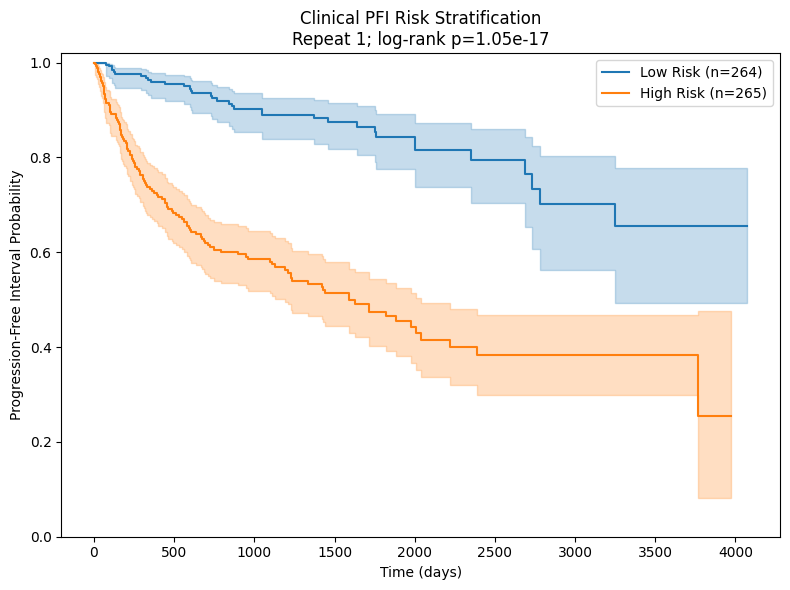

In [73]:
plot_km_for_repeat(
    repeated_clinical_predictions,
    "Clinical_Risk",
    "Clinical",
    repeat=PLOT_REPEAT
)

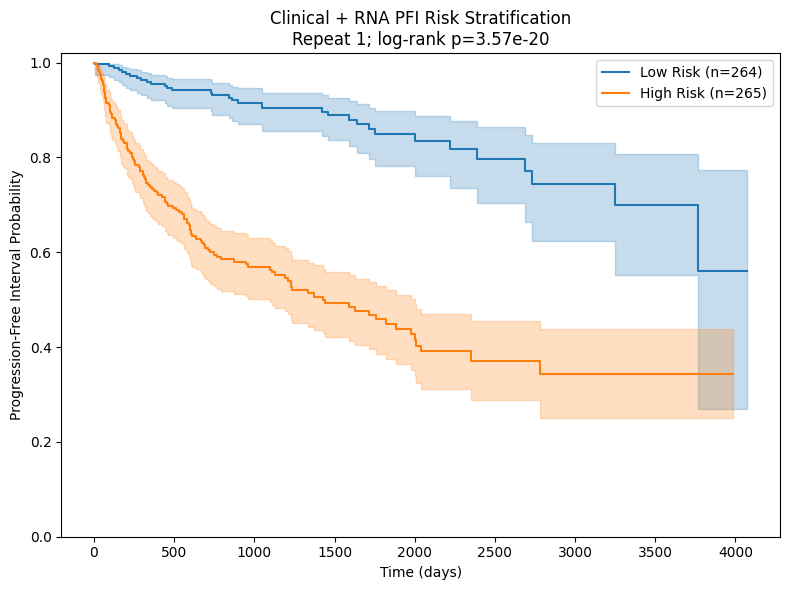

In [74]:
plot_km_for_repeat(
    repeated_multimodal_predictions,
    "Multimodal_Risk",
    "Clinical + RNA",
    repeat=PLOT_REPEAT
)

In [75]:
all_km_results.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_KM_risk_group_results_all_repeats.csv",
    index=False
)

km_summary.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_KM_risk_group_summary.csv",
    index=False
)

print("Kaplan-Meier analysis saved.")

Kaplan-Meier analysis saved.


In [76]:
CAL_TIMES = {
    "1yr": 365.0,
    "3yr": 1095.0,
    "5yr": 1825.0
}

def predict_survival_at_times(
    model,
    X,
    times
):
    surv_functions = model.predict_survival_function(X)

    probs = np.column_stack([
        [fn(t) for fn in surv_functions]
        for t in times
    ])

    return probs

print("Calibration helper loaded.")

Calibration helper loaded.


In [77]:
clinical_calibration_rows = []

for repeat in range(1, N_REPEATS + 1):

    print(f"Clinical calibration repeat {repeat}/{N_REPEATS}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(1, N_OUTER_FOLDS + 1):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            x for x in pfi_outcome.index
            if x not in test_ids
        ]

        X_train_df = clinical_features.loc[train_ids].copy()
        X_test_df = clinical_features.loc[test_ids].copy()

        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ])

        preprocessor = ColumnTransformer([
            (
                "numeric",
                numeric_pipeline,
                ["age"]
            ),
            (
                "categorical",
                categorical_pipeline,
                ["grade", "stage"]
            )
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_train = preprocessor.fit_transform(X_train_df)
            X_test = preprocessor.transform(X_test_df)

        y_train_df = pfi_outcome.loc[train_ids]

        y_train = Surv.from_arrays(
            event=y_train_df["event"].astype(bool).to_numpy(),
            time=y_train_df["time"].astype(float).to_numpy()
        )

        model = CoxPHSurvivalAnalysis(alpha=0.01)

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_train, y_train)

        probs = predict_survival_at_times(
            model,
            X_test,
            list(CAL_TIMES.values())
        )

        for i, case_id in enumerate(test_ids):

            clinical_calibration_rows.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,
                "PFI_event": int(
                    pfi_outcome.loc[case_id, "event"]
                ),
                "PFI_time": float(
                    pfi_outcome.loc[case_id, "time"]
                ),
                "S_1yr": float(probs[i, 0]),
                "S_3yr": float(probs[i, 1]),
                "S_5yr": float(probs[i, 2]),
                "Model": "Clinical"
            })

clinical_calibration = pd.DataFrame(
    clinical_calibration_rows
)

print(clinical_calibration.shape)
display(clinical_calibration.head())

Clinical calibration repeat 1/10
Clinical calibration repeat 2/10
Clinical calibration repeat 3/10
Clinical calibration repeat 4/10
Clinical calibration repeat 5/10
Clinical calibration repeat 6/10
Clinical calibration repeat 7/10
Clinical calibration repeat 8/10
Clinical calibration repeat 9/10
Clinical calibration repeat 10/10
(5290, 9)


,Repeat,Fold,Case ID,PFI_event,PFI_time,S_1yr,S_3yr,S_5yr,Model
0,1,1,TCGA-A3-3316,0,1493.0,0.879528,0.774109,0.675144,Clinical
1,1,1,TCGA-A3-3328,0,1385.0,0.967027,0.935311,0.902485,Clinical
2,1,1,TCGA-A3-3362,0,1559.0,0.969774,0.940619,0.910354,Clinical
3,1,1,TCGA-A3-3363,0,319.0,0.928897,0.863195,0.797950,Clinical
4,1,1,TCGA-A3-3373,0,1621.0,0.950961,0.904575,0.857384,Clinical


In [78]:
rna_calibration_rows = []

for repeat in range(1, N_REPEATS + 1):

    print(f"RNA calibration repeat {repeat}/{N_REPEATS}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(1, N_OUTER_FOLDS + 1):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            x for x in pfi_outcome.index
            if x not in test_ids
        ]

        prep = preprocess_rna_train_test(
            counts_protein.loc[train_ids].copy(),
            counts_protein.loc[test_ids].copy(),
            min_count=10,
            min_fraction=0.20,
            top_k=250
        )

        X_train = prep["X_train"]
        X_test = prep["X_test"]

        y_train_df = pfi_outcome.loc[train_ids]

        y_train = Surv.from_arrays(
            event=y_train_df["event"].astype(bool).to_numpy(),
            time=y_train_df["time"].astype(float).to_numpy()
        )

        hyper = repeated_rna_results.loc[
            (repeated_rna_results["Repeat"] == repeat)
            &
            (repeated_rna_results["Fold"] == fold)
        ].iloc[0]

        model = CoxnetSurvivalAnalysis(
            l1_ratio=float(hyper["Best l1_ratio"]),
            alphas=[float(hyper["Best alpha"])],
            fit_baseline_model=True,
            max_iter=150000,
            tol=1e-6
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_train, y_train)

        probs = predict_survival_at_times(
            model,
            X_test,
            list(CAL_TIMES.values())
        )

        for i, case_id in enumerate(test_ids):

            rna_calibration_rows.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,
                "PFI_event": int(
                    pfi_outcome.loc[case_id, "event"]
                ),
                "PFI_time": float(
                    pfi_outcome.loc[case_id, "time"]
                ),
                "S_1yr": float(probs[i, 0]),
                "S_3yr": float(probs[i, 1]),
                "S_5yr": float(probs[i, 2]),
                "Model": "RNA"
            })

rna_calibration = pd.DataFrame(
    rna_calibration_rows
)

print(rna_calibration.shape)
display(rna_calibration.head())

RNA calibration repeat 1/10
RNA calibration repeat 2/10
RNA calibration repeat 3/10
RNA calibration repeat 4/10
RNA calibration repeat 5/10
RNA calibration repeat 6/10
RNA calibration repeat 7/10
RNA calibration repeat 8/10
RNA calibration repeat 9/10
RNA calibration repeat 10/10
(5290, 9)


,Repeat,Fold,Case ID,PFI_event,PFI_time,S_1yr,S_3yr,S_5yr,Model
0,1,1,TCGA-A3-3316,0,1493.0,0.785136,0.640074,0.509891,RNA
1,1,1,TCGA-A3-3328,0,1385.0,0.943874,0.898939,0.851431,RNA
2,1,1,TCGA-A3-3362,0,1559.0,0.933232,0.880332,0.824967,RNA
3,1,1,TCGA-A3-3363,0,319.0,0.963106,0.933013,0.900620,RNA
4,1,1,TCGA-A3-3373,0,1621.0,0.950897,0.911314,0.869187,RNA


In [79]:
multimodal_calibration_rows = []

for repeat in range(1, N_REPEATS + 1):

    print(f"Multimodal calibration repeat {repeat}/{N_REPEATS}")

    repeat_assignments = repeated_folds.loc[
        repeated_folds["Repeat"] == repeat
    ]

    for fold in range(1, N_OUTER_FOLDS + 1):

        test_ids = repeat_assignments.loc[
            repeat_assignments["Fold"] == fold,
            "Case ID"
        ].tolist()

        train_ids = [
            x for x in pfi_outcome.index
            if x not in test_ids
        ]

        # Clinical
        numeric_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])

        categorical_pipeline = Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop="first",
                    sparse_output=False
                )
            )
        ])

        clinical_preprocessor = ColumnTransformer([
            ("numeric", numeric_pipeline, ["age"]),
            (
                "categorical",
                categorical_pipeline,
                ["grade", "stage"]
            )
        ])

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")

            X_clin_train = clinical_preprocessor.fit_transform(
                clinical_features.loc[train_ids].copy()
            )

            X_clin_test = clinical_preprocessor.transform(
                clinical_features.loc[test_ids].copy()
            )

        # RNA
        prep = preprocess_rna_train_test(
            counts_protein.loc[train_ids].copy(),
            counts_protein.loc[test_ids].copy(),
            min_count=10,
            min_fraction=0.20,
            top_k=250
        )

        X_train = np.hstack([
            X_clin_train,
            prep["X_train"]
        ])

        X_test = np.hstack([
            X_clin_test,
            prep["X_test"]
        ])

        y_train_df = pfi_outcome.loc[train_ids]

        y_train = Surv.from_arrays(
            event=y_train_df["event"].astype(bool).to_numpy(),
            time=y_train_df["time"].astype(float).to_numpy()
        )

        hyper = repeated_multimodal_results.loc[
            (repeated_multimodal_results["Repeat"] == repeat)
            &
            (repeated_multimodal_results["Fold"] == fold)
        ].iloc[0]

        model = CoxnetSurvivalAnalysis(
            l1_ratio=float(hyper["Best l1_ratio"]),
            alphas=[float(hyper["Best alpha"])],
            fit_baseline_model=True,
            max_iter=150000,
            tol=1e-6
        )

        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model.fit(X_train, y_train)

        probs = predict_survival_at_times(
            model,
            X_test,
            list(CAL_TIMES.values())
        )

        for i, case_id in enumerate(test_ids):

            multimodal_calibration_rows.append({
                "Repeat": repeat,
                "Fold": fold,
                "Case ID": case_id,
                "PFI_event": int(
                    pfi_outcome.loc[case_id, "event"]
                ),
                "PFI_time": float(
                    pfi_outcome.loc[case_id, "time"]
                ),
                "S_1yr": float(probs[i, 0]),
                "S_3yr": float(probs[i, 1]),
                "S_5yr": float(probs[i, 2]),
                "Model": "Multimodal"
            })

multimodal_calibration = pd.DataFrame(
    multimodal_calibration_rows
)

print(multimodal_calibration.shape)
display(multimodal_calibration.head())

Multimodal calibration repeat 1/10
Multimodal calibration repeat 2/10
Multimodal calibration repeat 3/10
Multimodal calibration repeat 4/10
Multimodal calibration repeat 5/10
Multimodal calibration repeat 6/10
Multimodal calibration repeat 7/10
Multimodal calibration repeat 8/10
Multimodal calibration repeat 9/10
Multimodal calibration repeat 10/10
(5290, 9)


,Repeat,Fold,Case ID,PFI_event,PFI_time,S_1yr,S_3yr,S_5yr,Model
0,1,1,TCGA-A3-3316,0,1493.0,0.767059,0.594555,0.447901,Multimodal
1,1,1,TCGA-A3-3328,0,1385.0,0.947294,0.899280,0.848749,Multimodal
2,1,1,TCGA-A3-3362,0,1559.0,0.951137,0.906447,0.859220,Multimodal
3,1,1,TCGA-A3-3363,0,319.0,0.964476,0.931540,0.896238,Multimodal
4,1,1,TCGA-A3-3373,0,1621.0,0.951940,0.907949,0.861420,Multimodal


In [80]:
def make_calibration_table(
    df,
    horizon_label,
    horizon_time,
    n_bins=5
):
    rows = []

    prediction_col = f"S_{horizon_label}"

    for repeat in sorted(df["Repeat"].unique()):

        repeat_df = df.loc[
            df["Repeat"] == repeat
        ].copy()

        # Quantile groups based only on predicted survival
        repeat_df["Calibration Bin"] = pd.qcut(
            repeat_df[prediction_col],
            q=n_bins,
            labels=False,
            duplicates="drop"
        )

        for bin_id in sorted(
            repeat_df["Calibration Bin"].dropna().unique()
        ):

            group = repeat_df.loc[
                repeat_df["Calibration Bin"] == bin_id
            ].copy()

            kmf = KaplanMeierFitter()

            kmf.fit(
                durations=group["PFI_time"],
                event_observed=group["PFI_event"]
            )

            observed_survival = float(
                kmf.predict(horizon_time)
            )

            predicted_survival = float(
                group[prediction_col].mean()
            )

            rows.append({
                "Model": group["Model"].iloc[0],
                "Repeat": repeat,
                "Horizon": horizon_label,
                "Horizon_days": horizon_time,
                "Bin": int(bin_id),
                "N": len(group),
                "Mean_predicted_survival":
                    predicted_survival,
                "Observed_KM_survival":
                    observed_survival,
                "Calibration_error":
                    predicted_survival
                    - observed_survival,
                "Absolute_calibration_error":
                    abs(
                        predicted_survival
                        - observed_survival
                    )
            })

    return pd.DataFrame(rows)

print("Calibration-table helper loaded.")

Calibration-table helper loaded.


In [81]:
all_calibration_predictions = pd.concat(
    [
        clinical_calibration,
        rna_calibration,
        multimodal_calibration
    ],
    ignore_index=True
)

calibration_tables = []

for model in [
    "Clinical",
    "RNA",
    "Multimodal"
]:

    model_df = all_calibration_predictions.loc[
        all_calibration_predictions["Model"] == model
    ]

    for label, time in CAL_TIMES.items():

        table = make_calibration_table(
            model_df,
            horizon_label=label,
            horizon_time=time,
            n_bins=5
        )

        calibration_tables.append(table)

calibration_long = pd.concat(
    calibration_tables,
    ignore_index=True
)

display(calibration_long.head(20))

,Model,Repeat,Horizon,Horizon_days,Bin,N,Mean_predicted_survival,Observed_KM_survival,Calibration_error,Absolute_calibration_error
0,Clinical,1,1yr,365.0,0,106,0.496007,0.476929,0.019078,0.019078
1,Clinical,1,1yr,365.0,1,106,0.847445,0.856398,-0.008953,0.008953
2,Clinical,1,1yr,365.0,2,106,0.932671,0.940014,-0.007343,0.007343
3,Clinical,1,1yr,365.0,3,106,0.962383,0.979255,-0.016872,0.016872
4,Clinical,1,1yr,365.0,4,105,0.972437,0.969028,0.003408,0.003408
5,Clinical,2,1yr,365.0,0,107,0.497147,0.486116,0.011032,0.011032
6,Clinical,2,1yr,365.0,1,105,0.848357,0.874011,-0.025654,0.025654
7,Clinical,2,1yr,365.0,2,105,0.932601,0.928610,0.003990,0.003990
8,Clinical,2,1yr,365.0,3,106,0.962809,0.969238,-0.006429,0.006429
9,Clinical,2,1yr,365.0,4,106,0.973236,0.968832,0.004404,0.004404


In [82]:
calibration_summary = (
    calibration_long
    .groupby(
        ["Model", "Horizon"]
    )
    .agg(
        Mean_Absolute_Calibration_Error=(
            "Absolute_calibration_error",
            "mean"
        ),
        Median_Absolute_Calibration_Error=(
            "Absolute_calibration_error",
            "median"
        ),
        Mean_Calibration_Error=(
            "Calibration_error",
            "mean"
        ),
        SD_Calibration_Error=(
            "Calibration_error",
            "std"
        )
    )
    .reset_index()
)

display(calibration_summary)

,Model,Horizon,Mean_Absolute_Calibration_Error,Median_Absolute_Calibration_Error,Mean_Calibration_Error,SD_Calibration_Error
0,Clinical,1yr,0.010912,0.008399,-0.002513,0.013090
1,Clinical,3yr,0.022326,0.018474,-0.000968,0.027557
2,Clinical,5yr,0.025118,0.021631,0.006104,0.030737
3,Multimodal,1yr,0.028233,0.025109,-0.006535,0.033391
4,Multimodal,3yr,0.037178,0.032949,-0.014119,0.042330
5,Multimodal,5yr,0.049502,0.047129,-0.023769,0.053295
6,RNA,1yr,0.034213,0.030030,-0.002169,0.043022
7,RNA,3yr,0.033297,0.021654,-0.006313,0.043689
8,RNA,5yr,0.051953,0.041301,-0.015224,0.064843


In [83]:
mean_calibration_curve = (
    calibration_long
    .groupby(
        [
            "Model",
            "Horizon",
            "Bin"
        ]
    )
    .agg(
        Mean_Predicted=(
            "Mean_predicted_survival",
            "mean"
        ),
        Mean_Observed=(
            "Observed_KM_survival",
            "mean"
        ),
        SD_Observed=(
            "Observed_KM_survival",
            "std"
        ),
        Mean_N=(
            "N",
            "mean"
        )
    )
    .reset_index()
)

display(mean_calibration_curve)

,Model,Horizon,Bin,Mean_Predicted,Mean_Observed,SD_Observed,Mean_N
0,Clinical,1yr,0,0.493342,0.480101,0.002855,106.1
1,Clinical,1yr,1,0.849198,0.858801,0.010616,106.0
2,Clinical,1yr,2,0.932570,0.932759,0.009751,105.2
3,Clinical,1yr,3,0.962250,0.979266,0.010915,106.0
4,Clinical,1yr,4,0.973222,0.972221,0.005039,105.7
5,Clinical,3yr,0,0.257555,0.266542,0.006624,106.1
6,Clinical,3yr,1,0.708558,0.739137,0.019972,106.0
7,Clinical,3yr,2,0.862512,0.838779,0.019946,105.0
8,Clinical,3yr,3,0.921071,0.930423,0.024322,106.4
9,Clinical,3yr,4,0.944526,0.924182,0.017325,105.5


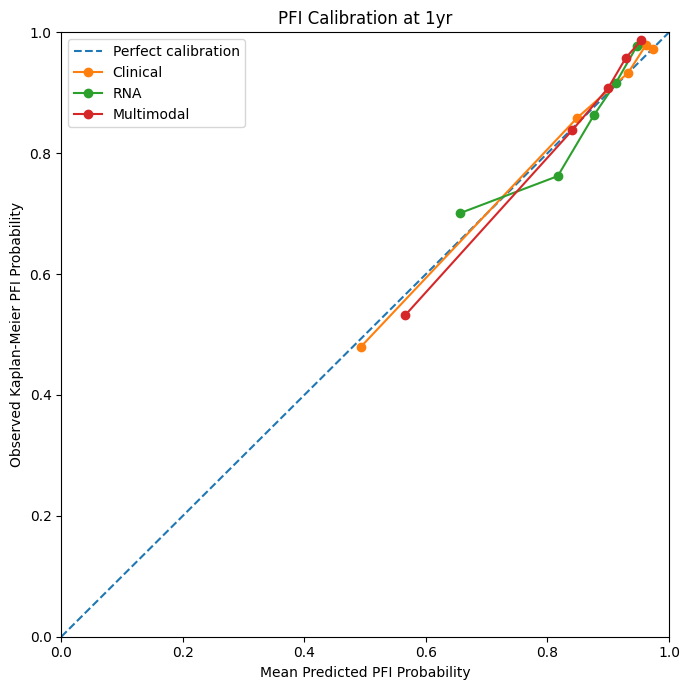

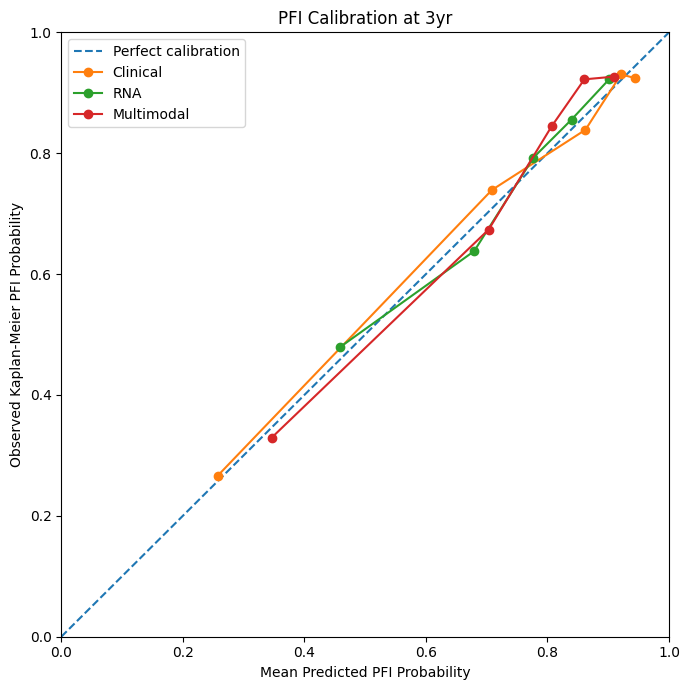

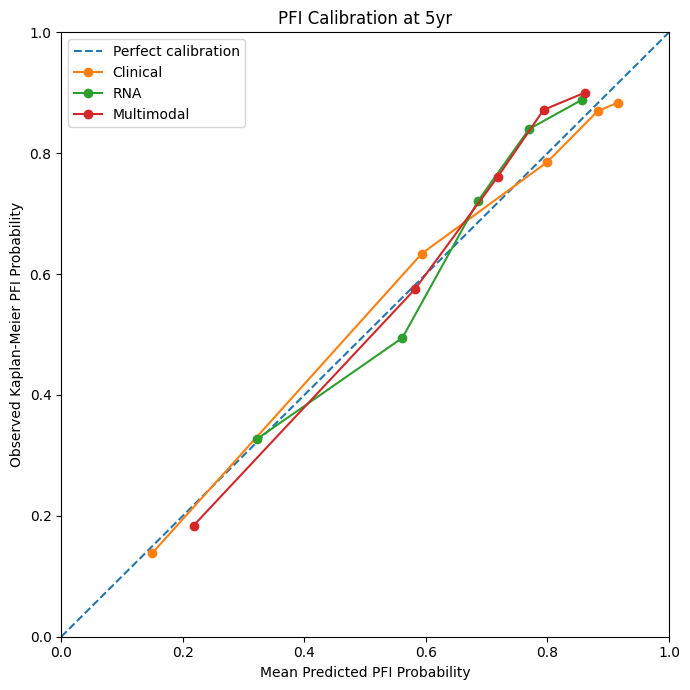

In [84]:
for horizon in [
    "1yr",
    "3yr",
    "5yr"
]:

    plt.figure(figsize=(7, 7))

    # Perfect calibration line
    plt.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration"
    )

    for model in [
        "Clinical",
        "RNA",
        "Multimodal"
    ]:

        plot_df = mean_calibration_curve.loc[
            (
                mean_calibration_curve["Model"] == model
            )
            &
            (
                mean_calibration_curve["Horizon"]
                == horizon
            )
        ].sort_values("Mean_Predicted")

        plt.plot(
            plot_df["Mean_Predicted"],
            plot_df["Mean_Observed"],
            marker="o",
            label=model
        )

    plt.xlabel("Mean Predicted PFI Probability")
    plt.ylabel("Observed Kaplan-Meier PFI Probability")

    plt.title(
        f"PFI Calibration at {horizon}"
    )

    plt.xlim(0, 1)
    plt.ylim(0, 1)

    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()

In [85]:
all_calibration_predictions.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_calibration_predictions.csv",
    index=False
)

calibration_long.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_calibration_bins_all_repeats.csv",
    index=False
)

calibration_summary.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_calibration_summary.csv",
    index=False
)

mean_calibration_curve.to_csv(
    processed_dir /
    "TCGA_KIRC_PFI_mean_calibration_curves.csv",
    index=False
)

print("Calibration analysis saved.")

Calibration analysis saved.


In [86]:
from pathlib import Path

publication_dir = project_dir / "04_publication_outputs"

publication_dir.mkdir(
    parents=True,
    exist_ok=True
)

print("Publication folder:")
print(publication_dir)

Publication folder:
C:\Multimodal_KIRC_Project\04_publication_outputs


In [87]:
master_performance_table = pd.DataFrame({
    "Model": [
        "Clinical",
        "RNA",
        "Clinical + RNA"
    ],

    "Repeated C-index Mean": [
        repeated_clinical_results["C-index"].mean(),
        repeated_rna_results["Outer C-index"].mean(),
        repeated_multimodal_results["Outer C-index"].mean()
    ],

    "Repeated C-index SD": [
        repeated_clinical_results["C-index"].std(ddof=1),
        repeated_rna_results["Outer C-index"].std(ddof=1),
        repeated_multimodal_results["Outer C-index"].std(ddof=1)
    ],

    "AUC 1-year": [
        0.855063,
        0.728314,
        0.834427
    ],

    "AUC 3-year": [
        0.821639,
        0.735735,
        0.813217
    ],

    "AUC 5-year": [
        0.819688,
        0.756181,
        0.806254
    ],

    "Brier 1-year": [
        0.093638,
        0.126066,
        0.104555
    ],

    "Brier 3-year": [
        0.134414,
        0.173840,
        0.143302
    ],

    "Brier 5-year": [
        0.157353,
        0.190799,
        0.164735
    ],

    "IBS 1-5 years": [
        0.131010,
        0.169536,
        0.139939
    ],

    "Mean Log-rank Chi-square": [
        76.242136,
        64.948875,
        97.294407
    ],

    "Significant KM Repeats": [
        10,
        10,
        10
    ],

    "Calibration MAE 1-year": [
        0.010912,
        0.034213,
        0.028233
    ],

    "Calibration MAE 3-year": [
        0.022326,
        0.033297,
        0.037178
    ],

    "Calibration MAE 5-year": [
        0.025118,
        0.051953,
        0.049502
    ]
})

display(master_performance_table)

master_performance_table.to_csv(
    publication_dir /
    "Table_Master_Model_Performance.csv",
    index=False
)

print("Master performance table saved.")

,Model,Repeated C-index Mean,Repeated C-index SD,AUC 1-year,AUC 3-year,AUC 5-year,Brier 1-year,Brier 3-year,Brier 5-year,IBS 1-5 years,Mean Log-rank Chi-square,Significant KM Repeats,Calibration MAE 1-year,Calibration MAE 3-year,Calibration MAE 5-year
0,Clinical,0.812006,0.037360,0.855063,0.821639,0.819688,0.093638,0.134414,0.157353,0.131010,76.242136,10,0.010912,0.022326,0.025118
1,RNA,0.717280,0.030060,0.728314,0.735735,0.756181,0.126066,0.173840,0.190799,0.169536,64.948875,10,0.034213,0.033297,0.051953
2,Clinical + RNA,0.798910,0.036246,0.834427,0.813217,0.806254,0.104555,0.143302,0.164735,0.139939,97.294407,10,0.028233,0.037178,0.049502


Master performance table saved.


C:\Users\kumia\AppData\Local\Temp\ipykernel_17184\1257011642.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


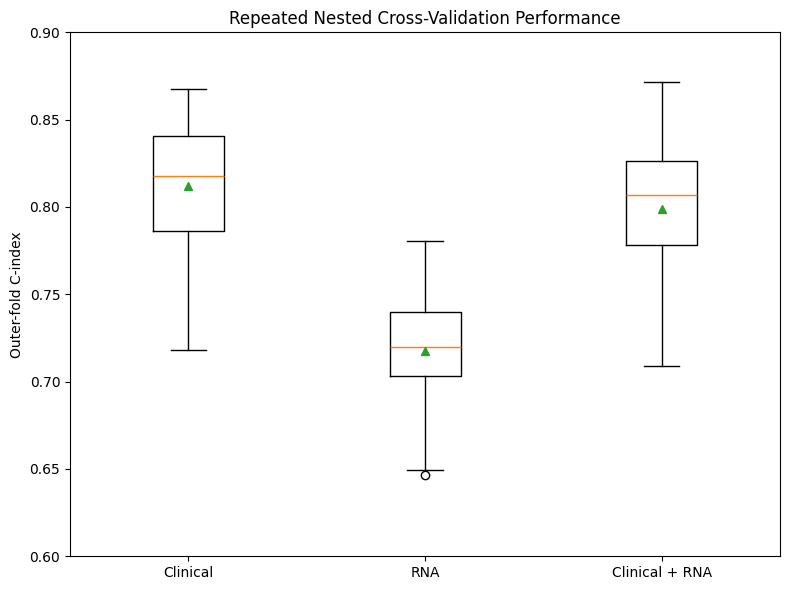

In [88]:
cindex_plot_df = pd.concat([
    pd.DataFrame({
        "Model": "Clinical",
        "C-index": repeated_clinical_results["C-index"]
    }),

    pd.DataFrame({
        "Model": "RNA",
        "C-index": repeated_rna_results["Outer C-index"]
    }),

    pd.DataFrame({
        "Model": "Clinical + RNA",
        "C-index": repeated_multimodal_results["Outer C-index"]
    })
], ignore_index=True)

plt.figure(figsize=(8, 6))

data_to_plot = [
    cindex_plot_df.loc[
        cindex_plot_df["Model"] == model,
        "C-index"
    ]
    for model in [
        "Clinical",
        "RNA",
        "Clinical + RNA"
    ]
]

plt.boxplot(
    data_to_plot,
    labels=[
        "Clinical",
        "RNA",
        "Clinical + RNA"
    ],
    showmeans=True
)

plt.ylabel("Outer-fold C-index")

plt.title(
    "Repeated Nested Cross-Validation Performance"
)

plt.ylim(0.60, 0.90)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure1_Repeated_Cindex.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure1_Repeated_Cindex.pdf",
    bbox_inches="tight"
)

plt.show()

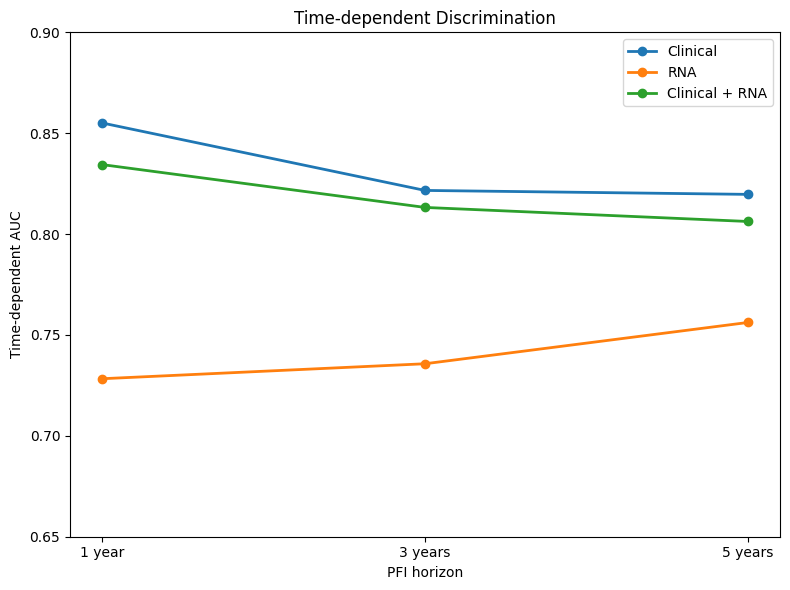

In [89]:
auc_plot = pd.DataFrame({
    "Horizon": [
        1, 3, 5
    ],

    "Clinical": [
        0.855063,
        0.821639,
        0.819688
    ],

    "RNA": [
        0.728314,
        0.735735,
        0.756181
    ],

    "Clinical + RNA": [
        0.834427,
        0.813217,
        0.806254
    ]
})

plt.figure(figsize=(8, 6))

for model in [
    "Clinical",
    "RNA",
    "Clinical + RNA"
]:
    plt.plot(
        auc_plot["Horizon"],
        auc_plot[model],
        marker="o",
        linewidth=2,
        label=model
    )

plt.xticks(
    [1, 3, 5],
    ["1 year", "3 years", "5 years"]
)

plt.ylabel("Time-dependent AUC")

plt.xlabel("PFI horizon")

plt.title(
    "Time-dependent Discrimination"
)

plt.ylim(0.65, 0.90)

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure2_Time_Dependent_AUC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure2_Time_Dependent_AUC.pdf",
    bbox_inches="tight"
)

plt.show()

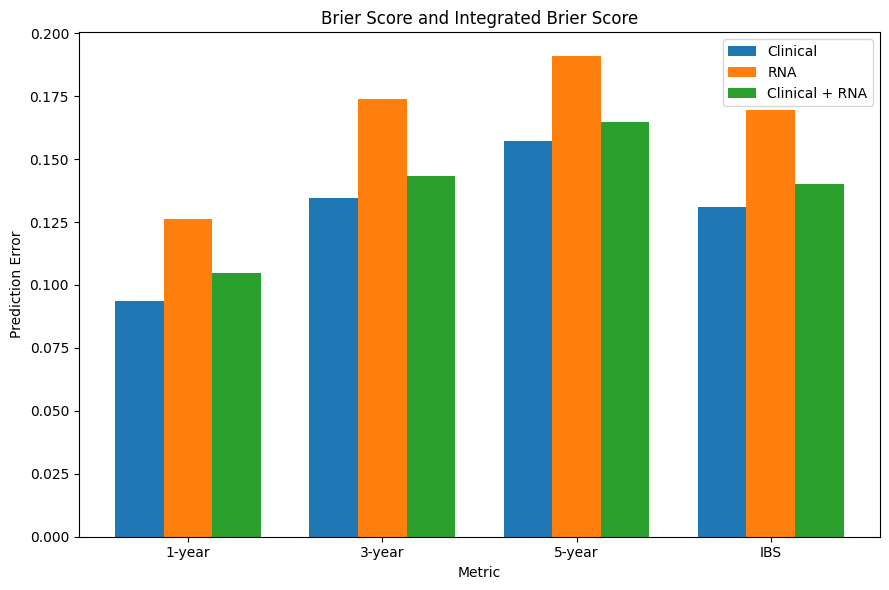

In [90]:
brier_plot = pd.DataFrame({
    "Metric": [
        "1-year",
        "3-year",
        "5-year",
        "IBS"
    ],

    "Clinical": [
        0.093638,
        0.134414,
        0.157353,
        0.131010
    ],

    "RNA": [
        0.126066,
        0.173840,
        0.190799,
        0.169536
    ],

    "Clinical + RNA": [
        0.104555,
        0.143302,
        0.164735,
        0.139939
    ]
})

x = np.arange(
    len(brier_plot)
)

width = 0.25

plt.figure(figsize=(9, 6))

plt.bar(
    x - width,
    brier_plot["Clinical"],
    width,
    label="Clinical"
)

plt.bar(
    x,
    brier_plot["RNA"],
    width,
    label="RNA"
)

plt.bar(
    x + width,
    brier_plot["Clinical + RNA"],
    width,
    label="Clinical + RNA"
)

plt.xticks(
    x,
    brier_plot["Metric"]
)

plt.ylabel("Prediction Error")

plt.xlabel("Metric")

plt.title(
    "Brier Score and Integrated Brier Score"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure3_Brier_IBS.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure3_Brier_IBS.pdf",
    bbox_inches="tight"
)

plt.show()

In [91]:
def km_panel_data(
    prediction_df,
    risk_column,
    repeat=1
):

    df = prediction_df.loc[
        prediction_df["Repeat"] == repeat
    ].copy()

    cutoff = df[risk_column].median()

    df["Risk Group"] = np.where(
        df[risk_column] >= cutoff,
        "High Risk",
        "Low Risk"
    )

    return df

In [92]:
clinical_km_plot = km_panel_data(
    repeated_clinical_predictions,
    "Clinical_Risk",
    repeat=1
)

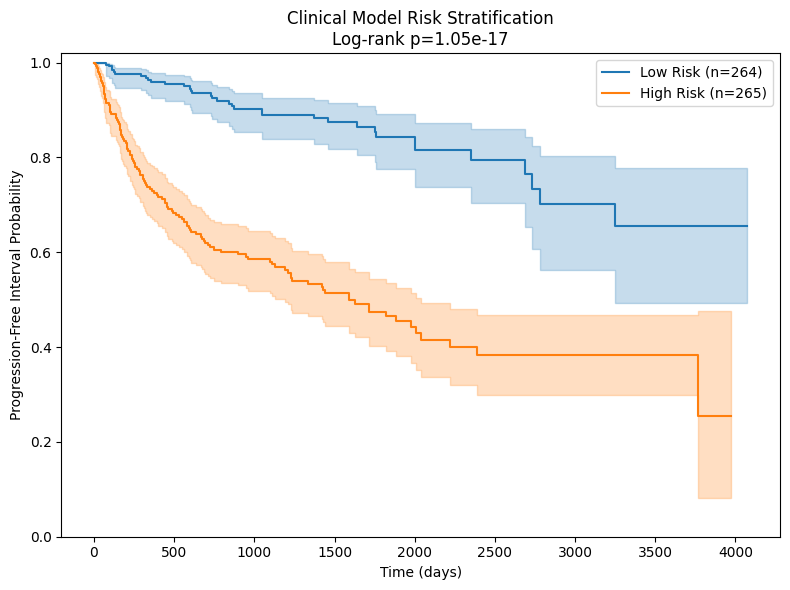

In [93]:
plt.figure(figsize=(8, 6))

km_low = KaplanMeierFitter()
km_high = KaplanMeierFitter()

low = clinical_km_plot.loc[
    clinical_km_plot["Risk Group"] == "Low Risk"
]

high = clinical_km_plot.loc[
    clinical_km_plot["Risk Group"] == "High Risk"
]

result = logrank_test(
    high["PFI_time"],
    low["PFI_time"],
    event_observed_A=high["PFI_event"],
    event_observed_B=low["PFI_event"]
)

km_low.fit(
    low["PFI_time"],
    low["PFI_event"],
    label=f"Low Risk (n={len(low)})"
)

ax = km_low.plot_survival_function()

km_high.fit(
    high["PFI_time"],
    high["PFI_event"],
    label=f"High Risk (n={len(high)})"
)

km_high.plot_survival_function(
    ax=ax
)

plt.xlabel("Time (days)")
plt.ylabel("Progression-Free Interval Probability")

plt.title(
    f"Clinical Model Risk Stratification\n"
    f"Log-rank p={result.p_value:.2e}"
)

plt.ylim(0, 1.02)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure4A_Clinical_KM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure4A_Clinical_KM.pdf",
    bbox_inches="tight"
)

plt.show()

In [94]:
plt.figure(figsize=(8, 6))

km_low = KaplanMeierFitter()
km_high = KaplanMeierFitter()

low = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "Low Risk"
]

high = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "High Risk"
]

result = logrank_test(
    high["PFI_time"],
    low["PFI_time"],
    event_observed_A=high["PFI_event"],
    event_observed_B=low["PFI_event"]
)

km_low.fit(
    low["PFI_time"],
    low["PFI_event"],
    label=f"Low Risk (n={len(low)})"
)

ax = km_low.plot_survival_function()

km_high.fit(
    high["PFI_time"],
    high["PFI_event"],
    label=f"High Risk (n={len(high)})"
)

km_high.plot_survival_function(
    ax=ax
)

plt.xlabel("Time (days)")
plt.ylabel("Progression-Free Interval Probability")

plt.title(
    f"Clinical + RNA Risk Stratification\n"
    f"Log-rank p={result.p_value:.2e}"
)

plt.ylim(0, 1.02)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.pdf",
    bbox_inches="tight"
)

plt.show()

NameError: name 'multi_km_plot' is not defined

<Figure size 800x600 with 0 Axes>

Low-risk patients: 264
High-risk patients: 265
Low-risk events: 34
High-risk events: 125
Log-rank chi-square: 84.64290672340327
Log-rank p-value: 3.5742390960528837e-20


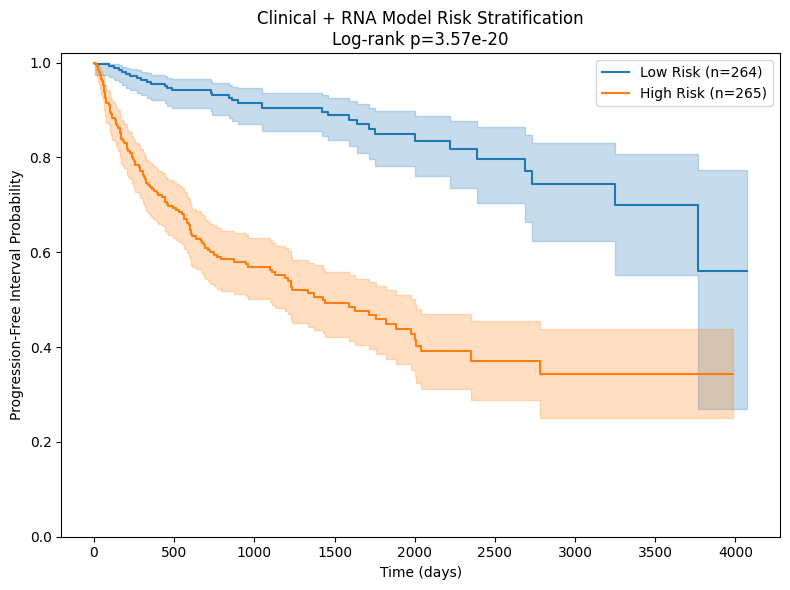

Multimodal Kaplan-Meier figure saved.


In [95]:
# ============================================================
# MULTIMODAL KAPLAN-MEIER PLOT
# Clinical + RNA
# ============================================================

PLOT_REPEAT = 1

# Get Repeat 1 out-of-fold multimodal predictions
multi_km_plot = repeated_multimodal_predictions.loc[
    repeated_multimodal_predictions["Repeat"] == PLOT_REPEAT
].copy()

# Median predicted-risk cutoff
median_risk = multi_km_plot[
    "Multimodal_Risk"
].median()

# Create high/low risk groups
multi_km_plot["Risk Group"] = np.where(
    multi_km_plot["Multimodal_Risk"] >= median_risk,
    "High Risk",
    "Low Risk"
)

# Separate groups
low = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "Low Risk"
].copy()

high = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "High Risk"
].copy()

print("Low-risk patients:", len(low))
print("High-risk patients:", len(high))
print("Low-risk events:", int(low["PFI_event"].sum()))
print("High-risk events:", int(high["PFI_event"].sum()))

# Log-rank test
result = logrank_test(
    high["PFI_time"],
    low["PFI_time"],
    event_observed_A=high["PFI_event"],
    event_observed_B=low["PFI_event"]
)

print(
    "Log-rank chi-square:",
    result.test_statistic
)

print(
    "Log-rank p-value:",
    result.p_value
)

# Kaplan-Meier estimators
km_low = KaplanMeierFitter()
km_high = KaplanMeierFitter()

plt.figure(figsize=(8, 6))

km_low.fit(
    durations=low["PFI_time"],
    event_observed=low["PFI_event"],
    label=f"Low Risk (n={len(low)})"
)

ax = km_low.plot_survival_function(
    ci_show=True
)

km_high.fit(
    durations=high["PFI_time"],
    event_observed=high["PFI_event"],
    label=f"High Risk (n={len(high)})"
)

km_high.plot_survival_function(
    ax=ax,
    ci_show=True
)

plt.xlabel("Time (days)")

plt.ylabel(
    "Progression-Free Interval Probability"
)

plt.title(
    "Clinical + RNA Model Risk Stratification\n"
    f"Log-rank p={result.p_value:.2e}"
)

plt.ylim(0, 1.02)

plt.grid(False)

plt.tight_layout()

# Save publication-quality PNG
plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.png",
    dpi=300,
    bbox_inches="tight"
)

# Save vector PDF
plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.pdf",
    bbox_inches="tight"
)

plt.show()

print(
    "Multimodal Kaplan-Meier figure saved."
)

In [96]:
def km_panel_data(
    prediction_df,
    risk_column,
    repeat=1
):

    df = prediction_df.loc[
        prediction_df["Repeat"] == repeat
    ].copy()

    cutoff = df[risk_column].median()

    df["Risk Group"] = np.where(
        df[risk_column] >= cutoff,
        "High Risk",
        "Low Risk"
    )

    return df

In [97]:
clinical_km_plot = km_panel_data(
    repeated_clinical_predictions,
    "Clinical_Risk",
    repeat=1
)

In [98]:
multi_km_plot = km_panel_data(
    repeated_multimodal_predictions,
    "Multimodal_Risk",
    repeat=1
)

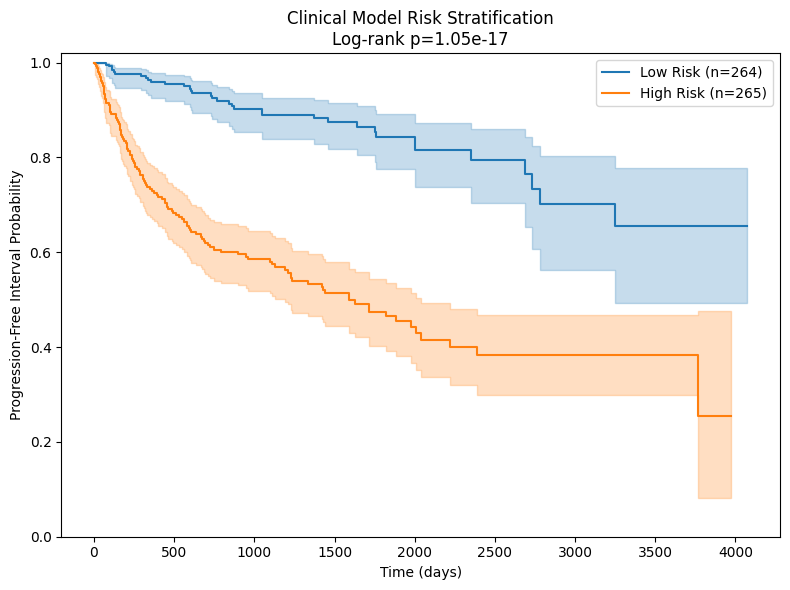

In [99]:
plt.figure(figsize=(8, 6))

km_low = KaplanMeierFitter()
km_high = KaplanMeierFitter()

low = clinical_km_plot.loc[
    clinical_km_plot["Risk Group"] == "Low Risk"
]

high = clinical_km_plot.loc[
    clinical_km_plot["Risk Group"] == "High Risk"
]

result = logrank_test(
    high["PFI_time"],
    low["PFI_time"],
    event_observed_A=high["PFI_event"],
    event_observed_B=low["PFI_event"]
)

km_low.fit(
    low["PFI_time"],
    low["PFI_event"],
    label=f"Low Risk (n={len(low)})"
)

ax = km_low.plot_survival_function()

km_high.fit(
    high["PFI_time"],
    high["PFI_event"],
    label=f"High Risk (n={len(high)})"
)

km_high.plot_survival_function(
    ax=ax
)

plt.xlabel("Time (days)")
plt.ylabel("Progression-Free Interval Probability")

plt.title(
    f"Clinical Model Risk Stratification\n"
    f"Log-rank p={result.p_value:.2e}"
)

plt.ylim(0, 1.02)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure4A_Clinical_KM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure4A_Clinical_KM.pdf",
    bbox_inches="tight"
)

plt.show()

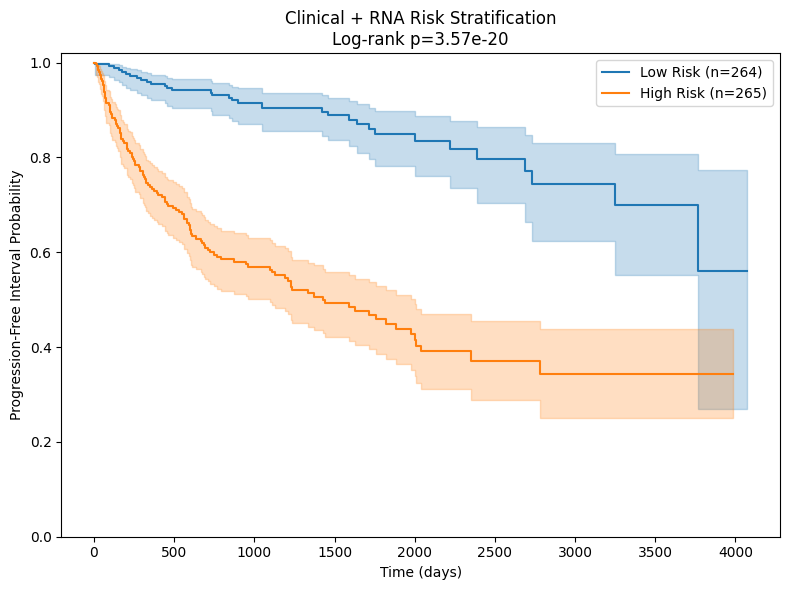

In [100]:
plt.figure(figsize=(8, 6))

km_low = KaplanMeierFitter()
km_high = KaplanMeierFitter()

low = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "Low Risk"
]

high = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "High Risk"
]

result = logrank_test(
    high["PFI_time"],
    low["PFI_time"],
    event_observed_A=high["PFI_event"],
    event_observed_B=low["PFI_event"]
)

km_low.fit(
    low["PFI_time"],
    low["PFI_event"],
    label=f"Low Risk (n={len(low)})"
)

ax = km_low.plot_survival_function()

km_high.fit(
    high["PFI_time"],
    high["PFI_event"],
    label=f"High Risk (n={len(high)})"
)

km_high.plot_survival_function(
    ax=ax
)

plt.xlabel("Time (days)")
plt.ylabel("Progression-Free Interval Probability")

plt.title(
    f"Clinical + RNA Risk Stratification\n"
    f"Log-rank p={result.p_value:.2e}"
)

plt.ylim(0, 1.02)

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.pdf",
    bbox_inches="tight"
)

plt.show()

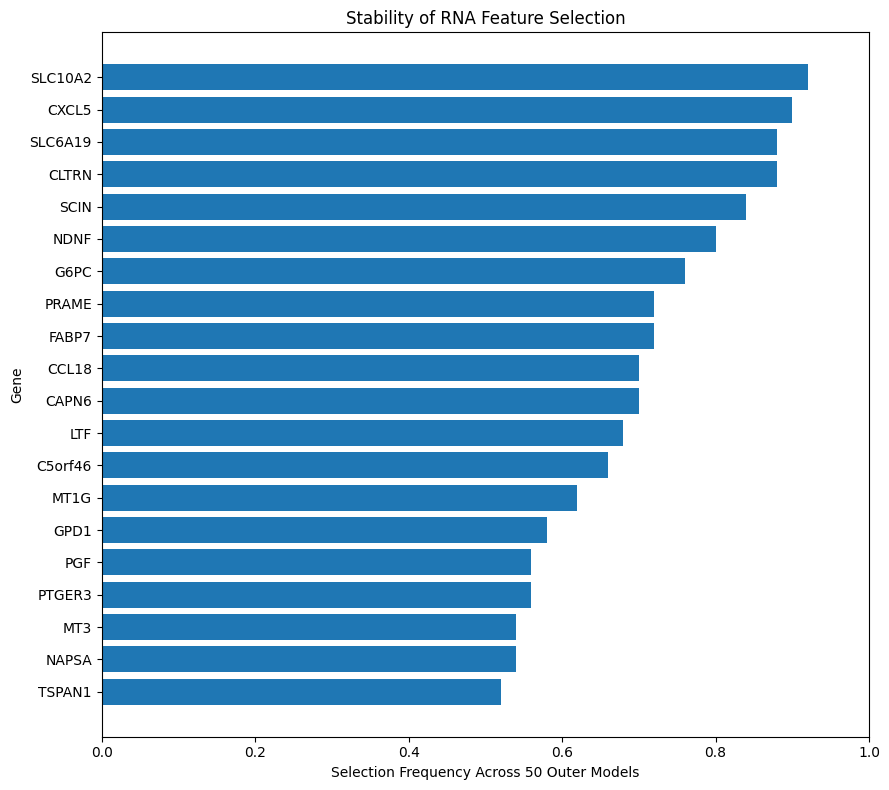

In [101]:
top_stable_genes = (
    repeated_gene_stability_annotated
    .sort_values(
        "Selection_Frequency",
        ascending=False
    )
    .head(20)
    .sort_values(
        "Selection_Frequency"
    )
)

plt.figure(figsize=(9, 8))

plt.barh(
    top_stable_genes["gene_name"],
    top_stable_genes["Selection_Frequency"]
)

plt.xlabel(
    "Selection Frequency Across 50 Outer Models"
)

plt.ylabel("Gene")

plt.title(
    "Stability of RNA Feature Selection"
)

plt.xlim(0, 1)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure5_Gene_Selection_Stability.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure5_Gene_Selection_Stability.pdf",
    bbox_inches="tight"
)

plt.show()

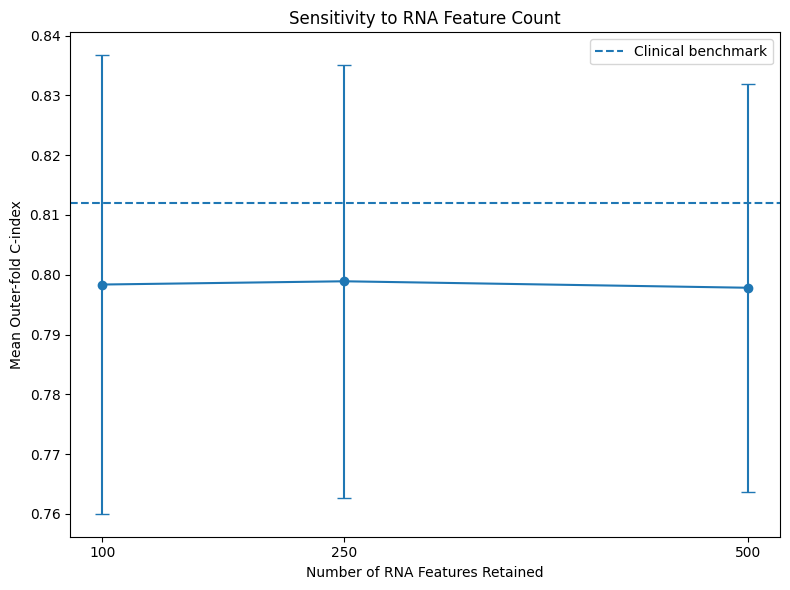

In [102]:
plt.figure(figsize=(8, 6))

plt.errorbar(
    topk_summary["Top K"],
    topk_summary["Mean"],
    yerr=topk_summary["SD"],
    marker="o",
    capsize=5
)

plt.axhline(
    repeated_clinical_results[
        "C-index"
    ].mean(),
    linestyle="--",
    label="Clinical benchmark"
)

plt.xlabel(
    "Number of RNA Features Retained"
)

plt.ylabel(
    "Mean Outer-fold C-index"
)

plt.title(
    "Sensitivity to RNA Feature Count"
)

plt.xticks(
    [100, 250, 500]
)

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure6_TopK_Sensitivity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure6_TopK_Sensitivity.pdf",
    bbox_inches="tight"
)

plt.show()

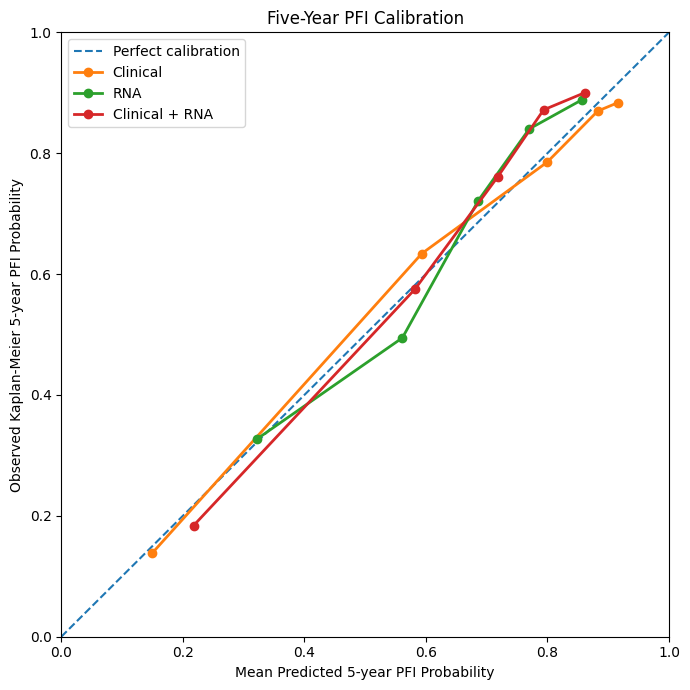

In [103]:
plt.figure(figsize=(7, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

for model in [
    "Clinical",
    "RNA",
    "Multimodal"
]:

    plot_df = (
        mean_calibration_curve.loc[
            (
                mean_calibration_curve["Model"]
                == model
            )
            &
            (
                mean_calibration_curve["Horizon"]
                == "5yr"
            )
        ]
        .sort_values(
            "Mean_Predicted"
        )
    )

    label = (
        "Clinical + RNA"
        if model == "Multimodal"
        else model
    )

    plt.plot(
        plot_df["Mean_Predicted"],
        plot_df["Mean_Observed"],
        marker="o",
        linewidth=2,
        label=label
    )

plt.xlabel(
    "Mean Predicted 5-year PFI Probability"
)

plt.ylabel(
    "Observed Kaplan-Meier 5-year PFI Probability"
)

plt.title(
    "Five-Year PFI Calibration"
)

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.savefig(
    publication_dir /
    "Figure7_5Year_Calibration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    publication_dir /
    "Figure7_5Year_Calibration.pdf",
    bbox_inches="tight"
)

plt.show()

In [104]:
stable_gene_table = (
    repeated_gene_stability_annotated
    .sort_values(
        "Selection_Frequency",
        ascending=False
    )
    .head(20)
    .copy()
)

stable_gene_table[
    "Selection_Percent"
] = (
    stable_gene_table[
        "Selection_Frequency"
    ] * 100
)

stable_gene_table = (
    stable_gene_table[
        [
            "gene_name",
            "gene_id",
            "Selection_Count",
            "Selection_Percent",
            "Repeats_Selected"
        ]
    ]
)

display(stable_gene_table)

stable_gene_table.to_csv(
    publication_dir /
    "Table_Stable_RNA_Genes.csv",
    index=False
)

,gene_name,gene_id,Selection_Count,Selection_Percent,Repeats_Selected
0,SLC10A2,ENSG00000125255.7,46,92.0,10
1,CXCL5,ENSG00000163735.7,45,90.0,10
2,CLTRN,ENSG00000147003.7,44,88.0,10
3,SLC6A19,ENSG00000174358.16,44,88.0,10
4,SCIN,ENSG00000006747.15,42,84.0,10
5,NDNF,ENSG00000173376.14,40,80.0,10
6,G6PC,ENSG00000131482.10,38,76.0,10
7,FABP7,ENSG00000164434.12,36,72.0,10
8,PRAME,ENSG00000185686.18,36,72.0,10
9,CAPN6,ENSG00000077274.9,35,70.0,10


In [105]:
publication_sensitivity_table = (
    topk_comparison_summary
    .merge(
        topk_wins,
        on="Top K"
    )
)

display(
    publication_sensitivity_table
)

publication_sensitivity_table.to_csv(
    publication_dir /
    "Table_TopK_Sensitivity.csv",
    index=False
)

,Top K,Mean_Multimodal_Cindex,Mean_Clinical_Cindex,Mean_Difference,SD_Difference,Multimodal beats Clinical,Total evaluations,Win proportion
0,100,0.798367,0.812006,-0.013639,0.035720,16,50,0.32
1,250,0.798910,0.812006,-0.013095,0.034384,15,50,0.30
2,500,0.797829,0.812006,-0.014177,0.036830,17,50,0.34


In [106]:
key_results = pd.DataFrame({
    "Result": [
        "Clinical mean repeated C-index",
        "RNA mean repeated C-index",
        "Multimodal mean repeated C-index",

        "Multimodal minus Clinical C-index",
        "Multimodal minus Clinical repeat-level CI lower",
        "Multimodal minus Clinical repeat-level CI upper",

        "Mean pairwise gene Jaccard",

        "Genes selected >= 40 of 50 models",

        "Multimodal KM mean log-rank chi-square",

        "Clinical IBS",
        "RNA IBS",
        "Multimodal IBS"
    ],

    "Value": [
        0.812006,
        0.717280,
        0.798910,

        -0.013095,
        -0.0188,
        -0.0062,

        0.325100,

        6,

        97.294407,

        0.131010,
        0.169536,
        0.139939
    ]
})

display(key_results)

key_results.to_csv(
    publication_dir /
    "Key_Manuscript_Results.csv",
    index=False
)

,Result,Value
0,Clinical mean repeated C-index,0.812006
1,RNA mean repeated C-index,0.717280
2,Multimodal mean repeated C-index,0.798910
3,Multimodal minus Clinical C-index,-0.013095
4,Multimodal minus Clinical repeat-level CI lower,-0.018800
5,Multimodal minus Clinical repeat-level CI upper,-0.006200
6,Mean pairwise gene Jaccard,0.325100
7,Genes selected >= 40 of 50 models,6.000000
8,Multimodal KM mean log-rank chi-square,97.294407
9,Clinical IBS,0.131010


Low-risk patients: 264
High-risk patients: 265
Low-risk events: 34
High-risk events: 125
Log-rank chi-square: 84.64290672340327
Log-rank p-value: 3.5742390960528837e-20


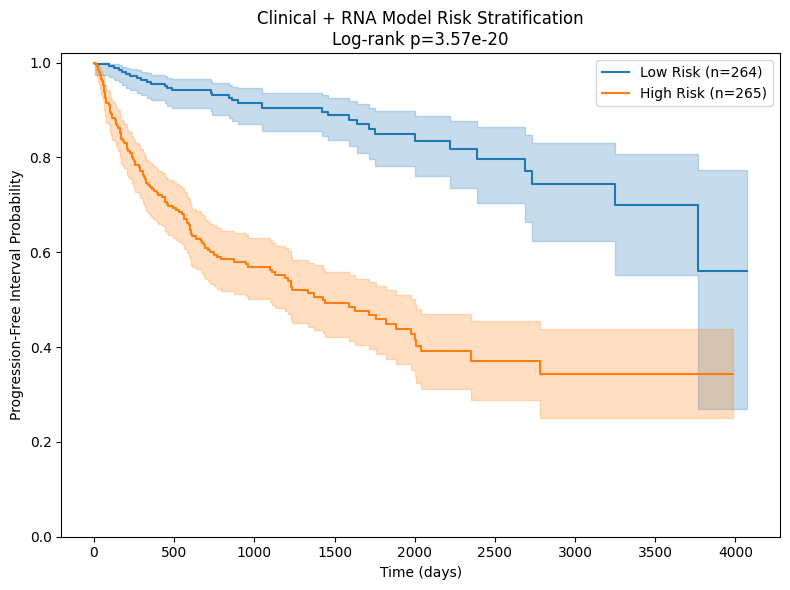

Multimodal Kaplan-Meier figure saved.


In [107]:
# ============================================================
# MULTIMODAL KAPLAN-MEIER PLOT
# Clinical + RNA
# ============================================================

PLOT_REPEAT = 1

# Get Repeat 1 out-of-fold multimodal predictions
multi_km_plot = repeated_multimodal_predictions.loc[
    repeated_multimodal_predictions["Repeat"] == PLOT_REPEAT
].copy()

# Median predicted-risk cutoff
median_risk = multi_km_plot[
    "Multimodal_Risk"
].median()

# Create high/low risk groups
multi_km_plot["Risk Group"] = np.where(
    multi_km_plot["Multimodal_Risk"] >= median_risk,
    "High Risk",
    "Low Risk"
)

# Separate groups
low = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "Low Risk"
].copy()

high = multi_km_plot.loc[
    multi_km_plot["Risk Group"] == "High Risk"
].copy()

print("Low-risk patients:", len(low))
print("High-risk patients:", len(high))
print("Low-risk events:", int(low["PFI_event"].sum()))
print("High-risk events:", int(high["PFI_event"].sum()))

# Log-rank test
result = logrank_test(
    high["PFI_time"],
    low["PFI_time"],
    event_observed_A=high["PFI_event"],
    event_observed_B=low["PFI_event"]
)

print(
    "Log-rank chi-square:",
    result.test_statistic
)

print(
    "Log-rank p-value:",
    result.p_value
)

# Kaplan-Meier estimators
km_low = KaplanMeierFitter()
km_high = KaplanMeierFitter()

plt.figure(figsize=(8, 6))

km_low.fit(
    durations=low["PFI_time"],
    event_observed=low["PFI_event"],
    label=f"Low Risk (n={len(low)})"
)

ax = km_low.plot_survival_function(
    ci_show=True
)

km_high.fit(
    durations=high["PFI_time"],
    event_observed=high["PFI_event"],
    label=f"High Risk (n={len(high)})"
)

km_high.plot_survival_function(
    ax=ax,
    ci_show=True
)

plt.xlabel("Time (days)")

plt.ylabel(
    "Progression-Free Interval Probability"
)

plt.title(
    "Clinical + RNA Model Risk Stratification\n"
    f"Log-rank p={result.p_value:.2e}"
)

plt.ylim(0, 1.02)

plt.grid(False)

plt.tight_layout()

# Save publication-quality PNG
plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.png",
    dpi=300,
    bbox_inches="tight"
)

# Save vector PDF
plt.savefig(
    publication_dir /
    "Figure4B_Multimodal_KM.pdf",
    bbox_inches="tight"
)

plt.show()

print(
    "Multimodal Kaplan-Meier figure saved."
)